# 02 — LDA em Folha de São Paulo (PT-BR)

## O que esse notebook faz

Aplica **Latent Dirichlet Allocation (LDA)** ao corpus Folha de São Paulo.
Pipeline idêntico ao padrão dos demais notebooks LDA — corpus formal PT-BR.

**Corpus:** Folha de São Paulo — PT-BR, formal/jornalístico, 2018-2024.
**Entrada:** `data/input/folha/corpus_limpo.csv`


## 1. Setup e imports

Carregamos parâmetros do `configs/params.yaml` (entrada `corpora.folha`), o seed global e as funções dos pipelines reusáveis:

- `_helpers.lemmatize_corpus(docs, lang, params)` → tokens lematizados + Dictionary com filter_extremes
- `_helpers.grid_search_k / train_lda / extract_topics_keywords / compute_doc_distributions` → fit e extração
- `_helpers.name_all_topics` → rotulagem via Ollama (modelo em `params.yaml`)
- `_helpers.*` → métricas (c_v, exclusivity, FREX, NPMI, etc.)

In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from gensim.models import LdaMulticore

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import lemmatize_corpus
from _helpers import (
    grid_search_k, grid_search_alpha_eta, train_lda, extract_topics_keywords,
    compute_doc_distributions, qualitative_report,
)
from _helpers import name_all_topics, name_topic
from _helpers import compute_coherence_npmi, compute_metrics_table, diagnose_cv_window
from _helpers import (
    compute_coherence_cv, compute_exclusivity, compute_exclusivity_ctfidf, compute_diversity,
    compute_topic_diversity, compute_frex_score, compute_stability,
    export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Carrega params do params.yaml
CORPUS_ID = "folha"
LANG = "pt"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]

print(f"corpus_id = {CORPUS_ID}")
print(f"text_column = {TEXT_COL}")
print(f"language = {LANG}")
print(f"seed = {seed}")
print(f"covariates (usadas no STM, não no LDA) = {cfg.get('covariates', [])}")

corpus_id = folha
text_column = message
language = pt
seed = 42
covariates (usadas no STM, não no LDA) = ['date', 'category']


## 2. Corpus Folha de São Paulo

### Origem e schema
- **Fonte:** CSV em `data/raw/folha/`
- **Idioma:** PT-BR, formal/jornalístico, 2018-2024
- **Schema:** `post_id`, `message`, `date`, `category` (editoria)



In [3]:
# Cell 3 — Carrega corpus_limpo.csv
# Resolve o corpus direto do output do 01-preprocessing (latest-wins, sem copia)
from _helpers import resolve_latest_dir
_corpus_dir = resolve_latest_dir(
    f"../../01-preprocessing/data/output/{CORPUS_ID}",
    contains="corpus_limpo.csv",
    fallback_dir=f"../data/input/{CORPUS_ID}",
)
CORPUS_VERSION = _corpus_dir.name
print(f"Versao do corpus: {CORPUS_VERSION}")
df = load_corpus(_corpus_dir)
docs = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()

# Subsample 5k (mesma seed=42 do BERTopic — treino e métricas no mesmo conjunto)
_s_idx = np.random.RandomState(42).choice(len(docs), min(5000, len(docs)), replace=False)
df = df.iloc[_s_idx].reset_index(drop=True)
docs = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()
print(f"Total docs: {len(docs):,} (subsample seed=42, padronizado com BERTopic)")
print(f"Colunas: {list(df.columns)}")
df.head(3)

  versão resolvida: folha_20260628_185652/ (latest)
Versao do corpus: folha_20260628_185652


Carregado: corpus_limpo.csv (4939 docs, SEM coluna 'sentiment' — rode 03-sentiment antes para ter cruzamento topic x sentiment automatico)
Total docs: 4,939 (subsample seed=42, padronizado com BERTopic)
Colunas: ['post_id', 'message', 'message_raw', 'title', 'data', 'category', 'platform']


,post_id,message,message_raw,title,data,category,platform
0,post_1972,A China se prepara para vacinar crianças a par...,A China se prepara para vacinar crianças a par...,China pretende aplicar a vacina Coronavac em c...,2021-06-09 13:15:00.0000000,equilibrioesaude,folha_uol
1,post_4567,Quatro meses antes de deixar prescrever um pro...,Quatro meses antes de deixar prescrever um pro...,Justiça deixou prescrever processo contra Edir...,2019-11-26 08:00:00.0000000,poder,folha_uol
2,post_0151,Não é normal que chimpanzés andem como os huma...,Não é normal que chimpanzés andem como os huma...,Os chimpanzés que caminham como humanos após a...,2019-08-01 11:53:00.0000000,ambiente,folha_uol


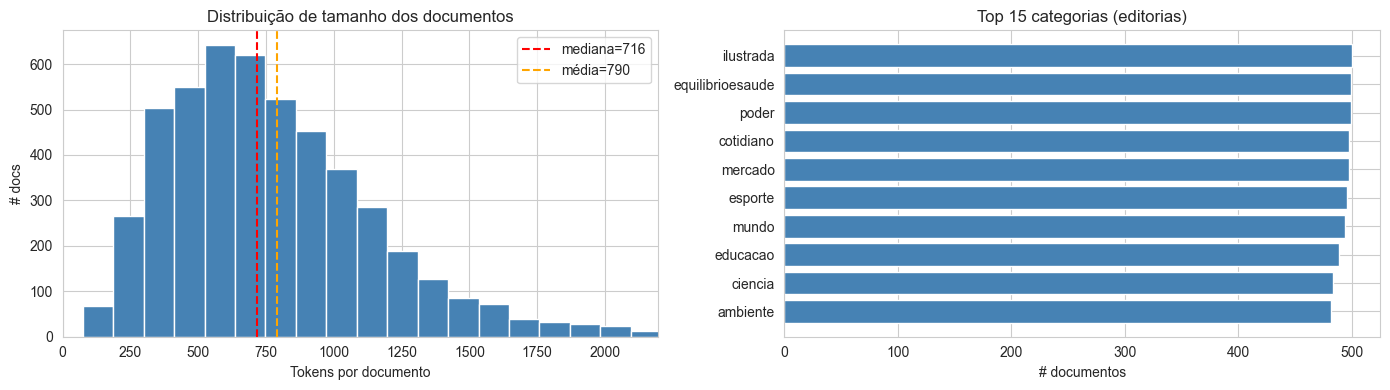


Descritivas n_tokens: {'count': 4939.0, 'mean': 790.0696497266653, 'std': 437.76195838317363, 'min': 75.0, '25%': 494.0, '50%': 716.0, '75%': 992.5, 'max': 6806.0}


In [4]:
# Cell 4 — Estatisticas descritivas + distribuicao de tokens
df["n_tokens"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["n_tokens"], bins=60, edgecolor="white", color="steelblue")
axes[0].axvline(df["n_tokens"].median(), color="red", linestyle="--", label=f'mediana={df["n_tokens"].median():.0f}')
axes[0].axvline(df["n_tokens"].mean(), color="orange", linestyle="--", label=f'média={df["n_tokens"].mean():.0f}')
axes[0].set_xlabel("Tokens por documento"); axes[0].set_ylabel("# docs")
axes[0].set_title("Distribuição de tamanho dos documentos"); axes[0].legend()
axes[0].set_xlim(0, df["n_tokens"].quantile(0.99))

cat_counts = df["category"].value_counts().head(15)
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[1].set_xlabel("# documentos"); axes[1].set_title("Top 15 categorias (editorias)")
plt.tight_layout(); plt.show()

print(f"\nDescritivas n_tokens: {df['n_tokens'].describe().to_dict()}")

## 3. Lematização e construção do vocabulário

### O que `_helpers.lemmatize_corpus` faz

1. Carrega spaCy `pt_core_news_lg` (cached em module-level)
2. Para cada doc: tokeniza, descarta stopwords (lista interna spaCy) + tokens não-alfa + tokens curtos (`len(lemma) <= 2`)
3. Constrói gensim `Dictionary` com `filter_extremes(no_below=5, no_above=0.5)`:
   - Remove palavras que aparecem em <5 docs (raras, ruído)
   - Remove palavras em >50% dos docs (genéricas, sem poder discriminante — ex.: "disse")

### Por que lematizar (vs stemming)

- Lematização preserva forma legível (`correndo` → `correr`; stemming agressivo produziria `corr`)
- Mais interpretável para a banca da dissertação
- Custo: ~30s a ~3min em CPU dependendo do volume

In [5]:
# Cell 5 — Lematiza corpus
print("Lematizando (single-process spaCy pt_core_news_lg)...")
t0 = time.time()
tokenized, dictionary = lemmatize_corpus(docs, LANG, params)
print(f"  done em {time.time()-t0:.0f}s")
print(f"  vocab final: {len(dictionary):,} palavras (após filter_extremes)")

# Estatísticas dos tokens lemmatizados
n_tokens_lemma = [len(t) for t in tokenized]
n_unique = [len(set(t)) for t in tokenized]

print(f"\n  avg tokens/doc após lemmatize: {np.mean(n_tokens_lemma):.1f}")
print(f"  avg unique tokens/doc: {np.mean(n_unique):.1f}")


Lematizando (single-process spaCy pt_core_news_lg)...


  done em 401s
  vocab final: 17,335 palavras (após filter_extremes)

  avg tokens/doc após lemmatize: 377.3
  avg unique tokens/doc: 240.6


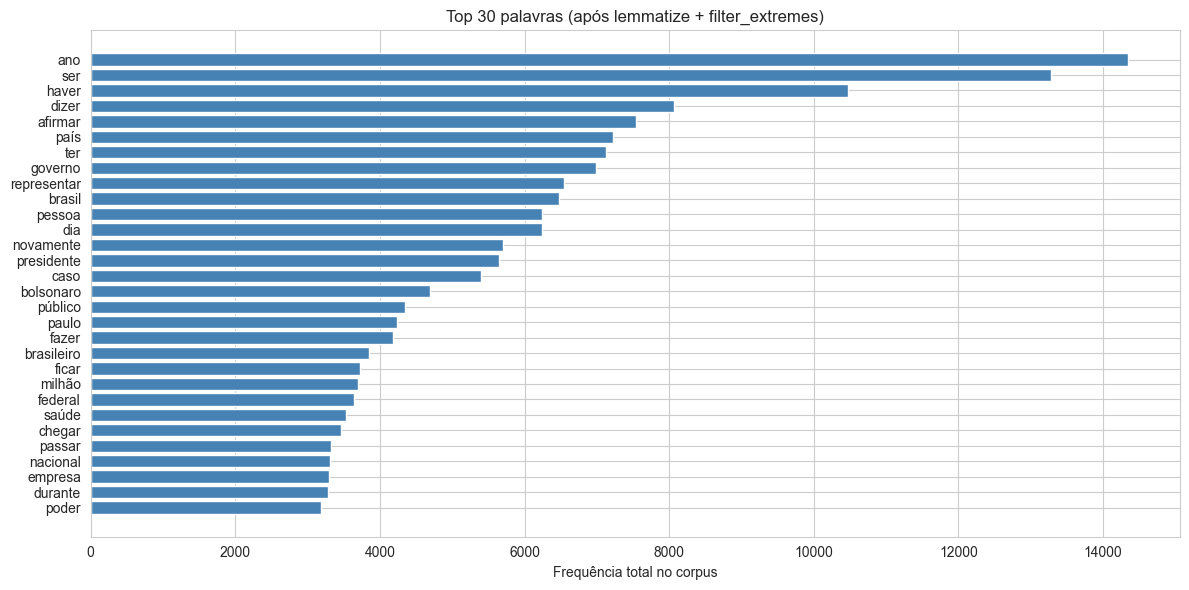

In [6]:
# Cell 6 — Top 30 palavras mais frequentes no vocabulário final
all_tokens = [t for doc in tokenized for t in doc]
freq = Counter(all_tokens)
top30 = freq.most_common(30)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*top30)
ax.barh(words[::-1], counts[::-1], color="steelblue")
ax.set_xlabel("Frequência total no corpus")
ax.set_title("Top 30 palavras (após lemmatize + filter_extremes)")
plt.tight_layout(); plt.show()

In [7]:
# Cell 7 — Bag-of-Words representation
corpus_bow = [dictionary.doc2bow(d) for d in tokenized]
print(f"corpus_bow: {len(corpus_bow):,} docs")
print(f"avg unique tokens/doc no BoW: {np.mean([len(b) for b in corpus_bow]):.1f}")
print(f"\nExemplo doc[0] BoW (primeiros 10 pares (word_id, count)):")
for word_id, count in corpus_bow[0][:10]:
    print(f"  {dictionary[word_id]:20s}  count={count}")

corpus_bow: 4,939 docs
avg unique tokens/doc no BoW: 219.2

Exemplo doc[0] BoW (primeiros 10 pares (word_id, count)):
  acesso                count=1
  acrescentar           count=1
  administrar           count=2
  administração         count=1
  adolescente           count=2
  adulto                count=1
  afp                   count=1
  alaska                count=1
  anunciar              count=1
  aplicar               count=2


## 4. Seleção de K (número de tópicos)

### Por que K importa

K é o **único hiperparâmetro estrutural** do LDA. Influencia a granularidade dos tópicos:
- K muito baixo → tópicos macro/genéricos (varios temas misturados em um)
- K muito alto → fragmentação (mesmo tema dividido em múltiplos clusters)

### Como escolher

Padrão na literatura: rodar LDA em vários K, calcular **c_v coherence** (Roder et al. 2015) — métrica que combina:
- co-ocorrência das top-N palavras numa janela deslizante
- score NPMI normalizado
- agregação via cosine similarity

Limitação conhecida: **c_v penaliza K alto** (Stevens et al. 2012). Por isso complementamos com inspeção qualitativa em múltiplos K (próxima célula).

In [8]:
# Cell 8 — Grid search K (carrega resultado do run standalone se existir)
from _helpers import make_run_output_dir
BASE_OUTPUT_DIR = Path(f"../data/output/{CORPUS_ID}/lda")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Saida carimbada por execucao: <corpus>_<data>_<hora> (nao sobrescreve runs anteriores)
OUTPUT_DIR = make_run_output_dir(BASE_OUTPUT_DIR, CORPUS_ID)
out_dir = str(OUTPUT_DIR)
# Cache do grid search: le/persiste no diretorio-BASE (reutiliza entre runs)
m_path = f"{BASE_OUTPUT_DIR}/lda_metrics.csv"

# --- ADICAO 2026-08-16 (protocolo): o cache de grid e PEGAJOSO — roda uma vez e
#     sobrevive a toda mudanca de codigo posterior (mapeamento secao 2.11.A). Sob o
#     protocolo novo o eixo de ordenacao passou a ser o NPMI, entao um cache SEM a
#     curva de NPMI esta desatualizado por definicao e precisa ser recomputado.
#     Esta e a invalidacao declarada que a P14 pedia: nao se apaga arquivo na mao.
_cache_tem_npmi = False
_cache_tem_diversity = False
if os.path.exists(m_path):
    _m_chk = pd.read_csv(m_path)
    _cache_tem_npmi = ("k_npmi_scores" in _m_chk.columns
                       and pd.notna(_m_chk.iloc[0].get("k_npmi_scores")))
    _cache_tem_diversity = ("k_diversity_scores" in _m_chk.columns
                       and pd.notna(_m_chk.iloc[0].get("k_diversity_scores")))
    if not (_cache_tem_npmi and _cache_tem_diversity):
        print("Cache do grid sem k_npmi_scores/k_diversity_scores (pre-protocolo 2026-08-22) — recomputando.")

if os.path.exists(m_path) and _cache_tem_npmi and _cache_tem_diversity:
    m = pd.read_csv(m_path)
    scores = ast.literal_eval(m.iloc[0]["k_grid_scores"])
    scores = {int(k): float(v) for k, v in scores.items()}
    npmi_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_npmi_scores"])).items()}
    div_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_diversity_scores"])).items()}
    _pkey = "k_perplexity_scores"
    if _pkey in m.columns and pd.notna(m.iloc[0].get(_pkey)):
        perplexity_scores = ast.literal_eval(str(m.iloc[0][_pkey]))
        perplexity_scores = {int(k): float(v) for k, v in perplexity_scores.items()}
    else:
        perplexity_scores = {}
    print(f"Carregado grid pre-computado de {m_path}")
    print(f"  K range: {sorted(scores.keys())}")
    print(f"  passes: {m.iloc[0].get('grid_passes', '?')}")
else:
    K_RANGE = [3, 5, 7, 8, 10, 12, 15, 20, 25, 30]
    print(f"Rodando grid K em {K_RANGE} passes=20 (~13min)...")
    scores, perplexity_scores, npmi_scores, div_scores = grid_search_k(
        corpus_bow, dictionary, tokenized, K_RANGE, seed=seed, passes=20,
        top_k=10,
        return_npmi=True,
        return_diversity=True,
        checkpoint_path=BASE_OUTPUT_DIR / "lda_k_checkpoint.csv")
    print(f"Done.")

scores

Cache do grid sem k_npmi_scores/k_diversity_scores (pre-protocolo 2026-08-22) — recomputando.
Rodando grid K em [3, 5, 7, 8, 10, 12, 15, 20, 25, 30] passes=20 (~13min)...


Done.


{3: 0.4136911630821067,
 5: 0.5359171355414563,
 7: 0.5741216917524566,
 8: 0.6083331322001545,
 10: 0.6420525279503588,
 12: 0.6262769723095641,
 15: 0.6320839483264601,
 20: 0.6606972107375999,
 25: 0.6505753485389509,
 30: 0.6629017507591347}

Salvo: ..\data\output\folha\lda\lda_grid_k_cv.png


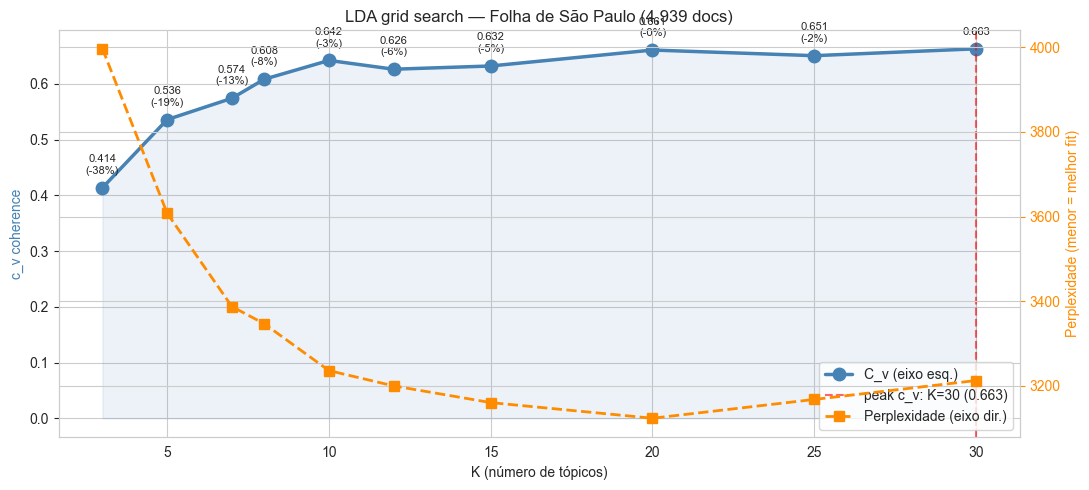


Peak: K=30 (c_v=0.6629)
K=10: c_v=0.6421 (delta vs peak: -3.1%)


In [9]:
# Cell 9 — Visualizacao c_v vs K
fig, ax = plt.subplots(figsize=(11, 5))
ks = sorted(scores)
vs = [scores[k] for k in ks]

ax.plot(ks, vs, marker="o", linewidth=2.5, markersize=9, color="steelblue", label="C_v (eixo esq.)")
ax.fill_between(ks, vs, alpha=0.1, color="steelblue")

peak_k = max(scores, key=scores.get)
ax.axvline(peak_k, color="red", linestyle="--", alpha=0.6, label=f"peak c_v: K={peak_k} ({scores[peak_k]:.3f})")

# Annotate each K
for k, v in zip(ks, vs):
    delta = (v - scores[peak_k]) / scores[peak_k] * 100
    label = f"{v:.3f}" if k == peak_k else f"{v:.3f}\n({delta:+.0f}%)"
    ax.annotate(label, (k, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)

ax.set_xlabel("K (número de tópicos)"); ax.set_ylabel("c_v coherence", color="steelblue")
ax.set_title(f"LDA grid search — Folha de São Paulo ({len(docs):,} docs)")
if perplexity_scores:
    ax2 = ax.twinx()
    pks = sorted(perplexity_scores)
    pvs = [perplexity_scores[k] for k in pks]
    ax2.plot(pks, pvs, marker="s", linewidth=2, markersize=7, color="darkorange",
             linestyle="--", label="Perplexidade (eixo dir.)")
    ax2.set_ylabel("Perplexidade (menor = melhor fit)", color="darkorange")
    ax2.tick_params(axis="y", colors="darkorange")
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines1, labels1 = ax.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
else:
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(BASE_OUTPUT_DIR / "lda_grid_k_cv.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {BASE_OUTPUT_DIR / 'lda_grid_k_cv.png'}")
plt.show()

print(f"\nPeak: K={peak_k} (c_v={scores[peak_k]:.4f})")
if 10 in scores:
    print(f"K=10: c_v={scores[10]:.4f} (delta vs peak: {(scores[10]-scores[peak_k])/scores[peak_k]*100:+.1f}%)")

## 5. Inspeção qualitativa multi-K

Como `c_v` favorece K menor, precisamos olhar **os tópicos em si** para escolher K com critério metodológico (não só estatístico). Carregamos os tópicos de K=5, 7, 10, 15, 30 pré-computados em `lda_multi_k_inspect.csv`, se disponível (execução prévia opcional — ver célula abaixo).

In [10]:
# Cell 10 — Multi-K topics side by side (opcional, requer lda_multi_k_inspect.csv pre-computado)
multi_path = f"{out_dir}/lda_multi_k_inspect.csv"
if os.path.exists(multi_path):
    multi = pd.read_csv(multi_path)
    for k_val in sorted(multi["k"].unique()):
        sub = multi[multi["k"] == k_val].sort_values("topic_id")
        print(f"=== K={k_val} ===")
        for _, row in sub.iterrows():
            kws = row["keywords"].split(", ")[:8]
            print(f"  T{int(row['topic_id']):2d}: {', '.join(kws)}")
        print()
else:
    print("lda_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).")

lda_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).


In [11]:
# Categorias canônicas da Folha para validação
if 'category' in df.columns:
    cat_dist = df['category'].value_counts()
    print('Distribuicao de categorias:')
    print(cat_dist.to_string())
else:
    print('Coluna category nao encontrada — pular validacao por categoria')


Distribuicao de categorias:
category
ilustrada           500
equilibrioesaude    499
poder               499
cotidiano           498
mercado             498
esporte             496
mundo               494
educacao            489
ciencia             484
ambiente            482


## 6. Decisão de K e treino final

**Trade-off:** `c_v` favorece K pequeno. Combine com inspeção qualitativa.
Ajuste `BEST_K` na célula abaixo se necessário.


Faixa de K declarada para folha: [15,30] (4 de 10 pontos admissiveis)
BEST_K pelo protocolo (secao 1.5): 15  (NPMI +0.1009)
  criterio: pareto NPMI x Diversity, desempate menor K
  NOTA: por C_v o argmax na faixa seria K=30 (C_v 0.6629 vs 0.6321 em K=15).
  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.

  K      NPMI       C_v   Perplex.   admissivel
    3  +0.0084  0.4137     3996.2       - 
    5  +0.0566  0.5359     3607.8       - 
    7  +0.0718  0.5741     3387.6       - 
    8  +0.0904  0.6083     3346.9       - 
   10  +0.1037  0.6421     3236.3       - 
   12  +0.0993  0.6263     3200.1       - 
   15  +0.1009  0.6321     3160.7      sim
   20  +0.1126  0.6607     3123.7      sim
   25  +0.1110  0.6506     3168.2      sim
   30  +0.1298  0.6629     3212.8      sim
Cache de alpha/eta e de K=30, mas BEST_K=15 — recomputando.
Grid alpha (5) × eta (3) = 15 combos, passes=10...


  done em 1304s
     alpha  eta       cv     npmi  perplexity  best_k
       0.5 0.01 0.583061 0.075155 4033.675553      15
       0.1 0.01 0.582134 0.074733 3880.429415      15
       0.5  NaN 0.581379 0.074611 3494.040978      15
       0.5 0.10 0.581852 0.074420 3438.679802      15
 symmetric  NaN 0.580316 0.074372 3355.051721      15
 symmetric 0.10 0.580887 0.074188 3296.859989      15
 symmetric 0.01 0.581390 0.074159 3872.760631      15
       0.1  NaN 0.579549 0.074112 3365.598568      15
       0.1 0.10 0.579917 0.073938 3307.830036      15
      0.01 0.01 0.580152 0.073710 3909.217096      15
      0.01  NaN 0.578762 0.073628 3357.024824      15
      0.01 0.10 0.578540 0.073340 3297.030456      15
asymmetric  NaN 0.582605 0.072483 3376.367589      15
asymmetric 0.01 0.580746 0.072083 3893.485729      15
asymmetric 0.10 0.579181 0.071035 3318.509655      15

  ★ best_alpha=0.5  best_eta=0.01


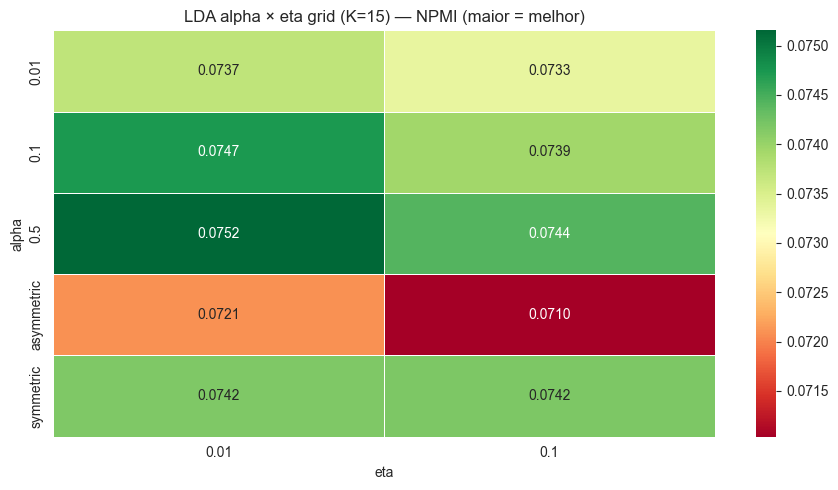


Treinando LDA K=15, alpha=0.5, eta=0.01, passes=20...


  done em 74s

Topics (top-10):
  T 0: ['empresa', 'milhão', 'bilhão', 'governo', 'recurso', 'projeto', 'mercado', 'pagar', 'setor', 'público']
  T 1: ['espacial', 'missão', 'terra', 'lua', 'nasa', 'voo', 'espaço', 'planeta', 'agência', 'lunar']
  T 2: ['brasil', 'governo', 'indígena', 'desmatamento', 'amazônia', 'ambiental', 'terra', 'bolsonaro', 'país', 'ambiente']
  T 3: ['país', 'eua', 'governo', 'americano', 'guerra', 'presidente', 'trump', 'china', 'militar', 'pessoa']
  T 4: ['saúde', 'caso', 'doença', 'paciente', 'pessoa', 'médico', 'morte', 'coronavírus', 'hospital', 'pandemia']
  T 5: ['brasileiro', 'jogo', 'clube', 'copa', 'futebol', 'time', 'equipe', 'jogador', 'brasil', 'seleção']
  T 6: ['bolsonaro', 'presidente', 'ministro', 'federal', 'governo', 'caso', 'ministério', 'público', 'justiça', 'tribunal']
  T 7: ['país', 'governo', 'economia', 'trabalho', 'inflação', 'econômico', 'mercado', 'brasil', 'reforma', 'acordo']
  T 8: ['pessoa', 'mulher', 'livro', 'vida', 'mundo', 

In [12]:
# Cell 12 — Grid alpha/eta (K=BEST_K fixo) + treino final
# --- PROTOCOLO 2026-08-16 (docs/protocolo-selecao-final-2026-08-16.md, secoes 4.1 e 4.2.1)
#     ANTES: BEST_K = argmax(C_v) sobre a grade inteira. Dois problemas, medidos:
#     (a) o eixo errado — o C_v degenera onde a janela de 110 tokens nao cabe, e o
#         protocolo ordena por NPMI (Bouma 2009), que e o par canonico do BERTopic e
#         o unico estimador que nao muda de regime entre os nossos dois corpora;
#     (b) sem a faixa declarada de K (restricao A3), todo criterio testado desce para
#         o extremo grosso da grade (secao 3.2, resultado 3). A faixa e SUBSTANTIVA e
#         declarada ANTES de olhar a grade — vem de _selecao.py, fonte unica.
from _selecao import FAIXA_K, _decidir_curva_k
_k_min, _k_max = FAIXA_K[CORPUS_ID]
_k_admissiveis = [k for k in npmi_scores if _k_min <= k <= _k_max]
if not _k_admissiveis:
    raise ValueError(
        f"nenhum K da grade {sorted(npmi_scores)} cai na faixa declarada "
        f"[{_k_min},{_k_max}] para {CORPUS_ID} — revise a grade ou a faixa, "
        f"mas declare a mudanca antes de olhar os resultados"
    )
_curvas_k = {"NPMI": npmi_scores, "Diversity": div_scores}
BEST_K, _criterio_k = _decidir_curva_k(_curvas_k, _k_min, _k_max)
if BEST_K is None:
    raise ValueError(f"_decidir_curva_k nao achou K admissivel: {_criterio_k}")
_best_k_cv = max(_k_admissiveis, key=lambda k: scores[k])

print(f"Faixa de K declarada para {CORPUS_ID}: [{_k_min},{_k_max}] "
      f"({len(_k_admissiveis)} de {len(npmi_scores)} pontos admissiveis)")
print(f"BEST_K pelo protocolo (secao 1.5): {BEST_K}  (NPMI {npmi_scores[BEST_K]:+.4f})")
print(f"  criterio: {_criterio_k}")
if _best_k_cv != BEST_K:
    print(f"  NOTA: por C_v o argmax na faixa seria K={_best_k_cv} "
          f"(C_v {scores[_best_k_cv]:.4f} vs {scores[BEST_K]:.4f} em K={BEST_K}).")
    print("  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.")

# Curva completa — reportar a CURVA, nao so o argmax (mapeamento secao 2.11: o argmax
# nao e estavel; a curva custa zero porque ja saiu do mesmo grid).
print("\n  K      NPMI       C_v   Perplex.   admissivel")
for _k in sorted(npmi_scores):
    _adm = "sim" if _k_min <= _k <= _k_max else " - "
    _pp = perplexity_scores.get(_k, float("nan"))
    print(f"  {_k:>3d}  {npmi_scores[_k]:+.4f}  {scores[_k]:.4f}  {_pp:9.1f}      {_adm}")

def _parse_ae_row(row):
    """Restaura tipos Python a partir de linha do CSV de cache."""
    alpha = str(row["alpha"])
    eta = row["eta"]
    if alpha not in ("symmetric", "asymmetric"):
        try: alpha = float(alpha)
        except: alpha = "symmetric"
    if pd.isna(eta) or str(eta) in ("None", "nan", ""):
        eta = None
    elif str(eta) != "auto":
        try: eta = float(eta)
        except: eta = None
    return alpha, eta

_ae_cache = f"{BASE_OUTPUT_DIR}/lda_alpha_eta_grid.csv"
_alpha_grid = params["evaluation"].get("lda_alpha_grid", ["symmetric", "asymmetric", 0.1, 0.5])
_eta_grid   = params["evaluation"].get("lda_eta_grid", [None, 0.01, 0.1])

# --- PROTOCOLO 2026-08-16: o cache de alpha/eta e tao pegajoso quanto o de K
#     (mapeamento secao 2.11.A) e era lido incondicionalmente — o 2o estagio do grid
#     podia ser PULADO INTEIRO, reusando um cache pre-git pontuado por C_v. Agora ele
#     so vale se trouxer a coluna npmi, que e o eixo do protocolo. Invalidacao
#     declarada: ninguem precisa apagar arquivo na mao.
_ae_valido = False
if os.path.exists(_ae_cache):
    _ae_chk = pd.read_csv(_ae_cache)
    _tem_npmi = "npmi" in _ae_chk.columns and _ae_chk["npmi"].notna().any()
    # O grid de alpha/eta e condicionado a K. Um cache gravado para outro K e
    # simplesmente o grid errado, e ate 2026-08-16 nada registrava para qual K
    # ele fora computado — o run de 16/08 carregou um cache gravado por uma
    # execucao anterior sem que houvesse como conferir a correspondencia.
    _k_do_cache = (int(_ae_chk["best_k"].iloc[0])
                   if "best_k" in _ae_chk.columns and pd.notna(_ae_chk["best_k"].iloc[0])
                   else None)
    _mesmo_k = (_k_do_cache == BEST_K)
    _ae_valido = _tem_npmi and _mesmo_k
    if not _tem_npmi:
        print("Cache de alpha/eta sem coluna npmi (pre-protocolo 2026-08-16) — recomputando.")
    elif _k_do_cache is None:
        print("Cache de alpha/eta sem carimbo de K — nao da para saber se e deste K. Recomputando.")
    elif not _mesmo_k:
        print(f"Cache de alpha/eta e de K={_k_do_cache}, mas BEST_K={BEST_K} — recomputando.")

if _ae_valido:
    ae_df = pd.read_csv(_ae_cache)
    best_alpha, best_eta = _parse_ae_row(ae_df.iloc[0])
    print(f"Grid alpha/eta carregado do cache ({_ae_cache}).")
else:
    print(f"Grid alpha ({len(_alpha_grid)}) × eta ({len(_eta_grid)}) = {len(_alpha_grid)*len(_eta_grid)} combos, passes=10...")
    t0 = time.time()
    ae_df, best_alpha, best_eta = grid_search_alpha_eta(
        corpus_bow, dictionary, tokenized, BEST_K,
        alpha_grid=_alpha_grid, eta_grid=_eta_grid, seed=seed, passes=10,
        score_by="npmi",   # mesmo eixo do estagio 1 — o protocolo exige coerencia entre estagios
        checkpoint_path=BASE_OUTPUT_DIR / "lda_alpha_eta_checkpoint.csv",
    )
    ae_df = ae_df.assign(best_k=BEST_K)   # carimbo: o grid de alpha/eta e condicionado a K
    ae_df.to_csv(_ae_cache, index=False)
    print(f"  done em {time.time()-t0:.0f}s")

print(ae_df.to_string(index=False))
print(f"\n  ★ best_alpha={best_alpha!r}  best_eta={best_eta!r}")

# Heatmap C_v por alpha × eta
if len(ae_df) > 1:
    # heatmap no eixo que DECIDE (NPMI); o C_v segue na tabela impressa acima
    _pivot = ae_df.pivot_table(index="alpha", columns="eta", values="npmi", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(9, max(3, len(_pivot) * 0.8 + 1)))
    sns.heatmap(_pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, linewidths=0.5)
    ax.set_title(f"LDA alpha × eta grid (K={BEST_K}) — NPMI (maior = melhor)")
    plt.tight_layout(); plt.show()

# Treino final com melhores hiperparâmetros
print(f"\nTreinando LDA K={BEST_K}, alpha={best_alpha!r}, eta={best_eta!r}, passes=20...")
t0 = time.time()
model = train_lda(corpus_bow, dictionary, k=BEST_K, seed=seed, passes=20, alpha=best_alpha, eta=best_eta)
print(f"  done em {time.time()-t0:.0f}s")

top_n = params["evaluation"]["top_n_keywords"]
topics_keywords = extract_topics_keywords(model, k=BEST_K, top_n=top_n)

print(f"\nTopics (top-{top_n}):")
for tid in sorted(topics_keywords):
    print(f"  T{tid:2d}: {topics_keywords[tid]}")

Salvo: ..\data\output\folha\lda\lda_grid_alpha_eta_heatmap.png

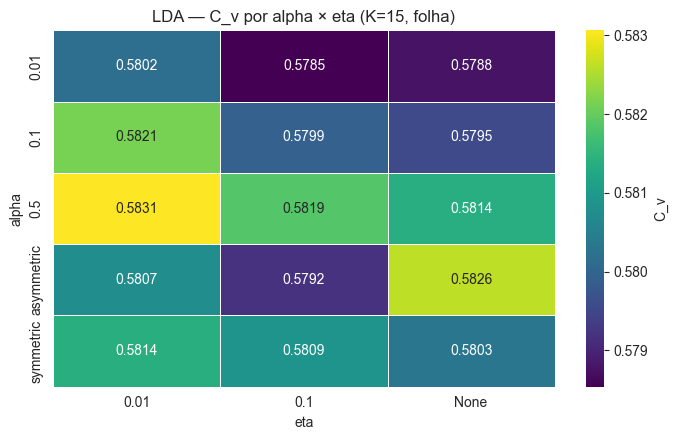

In [13]:
# Heatmap C_v do grid alpha x eta (lê o cache persistido no diretório-base)
_ae_csv = BASE_OUTPUT_DIR / "lda_alpha_eta_grid.csv"
if _ae_csv.exists():
    _g = pd.read_csv(_ae_csv)
    _g["eta"] = _g["eta"].fillna("None").astype(str)
    _g["alpha"] = _g["alpha"].astype(str)
    _piv = _g.pivot_table(index="alpha", columns="eta", values="cv")
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.heatmap(_piv, annot=True, fmt=".4f", cmap="viridis", linewidths=0.5, ax=ax,
                cbar_kws={"label": "C_v"})
    ax.set_title(f"LDA — C_v por alpha × eta (K={BEST_K}, {CORPUS_ID})")
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "lda_grid_alpha_eta_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'lda_grid_alpha_eta_heatmap.png'}")
    plt.show()
else:
    print("Sem lda_alpha_eta_grid.csv — heatmap pulado")

## 7. Rotulagem via LLM (Ollama)

`_helpers.name_all_topics` envia as keywords pro modelo configurado em `params.yaml` (`llm.model`) via Ollama com prompt few-shot em PT-BR. Em ~9s/tópico em CPU. Fallback: top-3 keywords se Ollama indisponível.

In [14]:
# === Nomeação LDA via LLM — pipeline melhorado ===
#
# Melhorias vs naming genérico anterior:
# - top_n_keywords_llm=50 (params.yaml; antes só 10 keywords passavam)
# - 3 docs representativos por probabilidade theta (antes: 0 docs)
# - Prompt PT-BR few-shot + anti-redundância + regra TEMA GERAL
# - Deduplicação pós-geração
# - Ordering por tamanho (maiores tópicos primeiro → nomes centrais primeiro)
# - /no_think removido (diretiva Qwen3; gemma2:2b ignora ou ecoa como texto)

llm_cfg = params.get("llm", {})
top_n_llm = params["evaluation"].get("top_n_keywords_llm", 50)

# ---- Extrai até top_n_llm keywords por tópico para o LLM ----
topics_keywords_llm = {
    tid: [w for w, _ in model.show_topic(tid, topn=top_n_llm)]
    for tid in range(BEST_K)
}

# ---- Docs representativos: 3 docs com maior probabilidade theta ----
# Computa distribuições inline se ainda não foram computadas
if "theta_arr" not in dir() or "dominant" not in dir():
    print("  theta_arr ausente — computando doc distributions inline...")
    _dom_tmp, _full_tmp = compute_doc_distributions(model, corpus_bow, k=BEST_K)
    theta_arr = np.array(_full_tmp)
    dominant = list(_dom_tmp)

N_REPR_DOCS_LDA = 3

def _representative_docs_lda(tid, n=N_REPR_DOCS_LDA):
    """3 docs com maior P(tópico|doc) para o tópico tid."""
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:n]
    return [docs[i] for i in top_idx]

# ---- Prompt PT-BR com few-shot + anti-redundância ----
_FEW_SHOT_LDA = """\
Exemplos de bom rótulo (frase nominal coerente):

  Palavras-chave: eleição, presidente, voto, urna, candidato, campanha
  Rótulo: Eleições presidenciais e campanha

  Palavras-chave: selic, juros, banco central, inflação, copom, mercado
  Rótulo: Política monetária e controle da inflação

  Palavras-chave: futebol, campeonato, time, jogador, gol, brasileirão
  Rótulo: Futebol e campeonato nacional

  Palavras-chave: stf, supremo, ministro, julgamento, lei, constituição
  Rótulo: Decisões do Supremo Tribunal Federal

  Palavras-chave: clima, chuva, temperatura, seca, enchente, alerta
  Rótulo: Eventos climáticos extremos no Brasil

  Palavras-chave: cinema, filme, série, streaming, roteiro, diretor
  Rótulo: Cinema, séries e produções audiovisuais

Exemplos de DOIS temas PRÓXIMOS nomeados de forma DISTINTA (faça assim):

  Palavras-chave: clima, emissões, energia, países, combustíveis, acordo
  Rótulo: Política climática e transição energética

  Palavras-chave: gelo, antártida, temperaturas, el niño, calor, degelo
  Rótulo: Aquecimento global e degelo polar

Exemplo de rótulo RUIM (NÃO faça assim):
  - "eleição, presidente, voto" (é LISTA de keywords, não rótulo)
"""


def _prompt_builder_lda(keywords, example_docs=None, assigned_names=None):
    keywords_str = ", ".join(keywords[:top_n_llm])
    avoid_block = ""
    if assigned_names:
        _listed = "\n".join(f"- {n}" for n in assigned_names)
        avoid_block = (
            "\nRÓTULOS já atribuídos (NÃO repita nem faça variação leve):\n"
            + _listed + "\n"
            "Se este tópico for parecido com algum acima, identifique o termo das "
            "palavras-chave que o DIFERENCIA e use-o no rótulo. NUNCA use sufixos "
            "como '(2)' ou '(gelo)'.\n\n"
        )
    docs_block = ""
    if example_docs:
        snippets = [
            f"[Documento {i + 1}]\n{d[:250].strip()}..."
            for i, d in enumerate(example_docs[:3])
        ]
        docs_block = "\n\nDocumentos representativos do tópico:\n" + "\n\n".join(snippets)
    return (
        "Você é um especialista em análise temática de notícias brasileiras.\n"
        "Crie um RÓTULO HUMANO LEGÍVEL (frase nominal PT-BR, 4-6 palavras).\n\n"
        + _FEW_SHOT_LDA + "\n" + avoid_block
        + "Agora nomeie este tópico:\n\n"
        f"Palavras-chave: {keywords_str}{docs_block}\n\n"
        "Regras:\n"
        "- Uma única frase nominal coerente (4-6 palavras).\n"
        "- As PRIMEIRAS palavras-chave são as mais importantes (maior peso): baseie o rótulo nelas.\n"
        "- Se as palavras misturarem dois assuntos, nomeie o ASSUNTO DOMINANTE (o das primeiras palavras), não uma mistura vaga.\n"
        "- Nomeie o TEMA GERAL comum aos documentos, não um evento isolado.\n"
        "- Rótulo CLARAMENTE DISTINTO dos já listados (use o termo que diferencia este tópico).\n"
        "- Sem aspas, sem prefixo 'Rótulo:', sem explicações.\n"
        "- Capitalize apenas a primeira palavra.\n\nRótulo:"
    )


_system_prompt_lda = (
    "Você é um especialista em análise temática de notícias brasileiras. "
    "Responda SEMPRE em português brasileiro com uma frase nominal curta (4-6 palavras). "
    "NUNCA use listas de palavras-chave separadas por vírgula."
)


def _dedupe_name_lda(name, keywords, used_lower):
    """Garante unicidade: keyword distintiva ou sufixo numérico."""
    if name.lower() not in used_lower:
        return name
    for kw in keywords:
        if kw.lower() not in name.lower():
            cand = f"{name} ({kw})"
            if cand.lower() not in used_lower:
                return cand
    i = 2
    while f"{name} ({i})".lower() in used_lower:
        i += 1
    return f"{name} ({i})"


# ---- Ordering por tamanho do tópico ----
_topic_counts_lda = pd.Series(dominant).value_counts().to_dict()
_order_lda = sorted(range(BEST_K), key=lambda t: -_topic_counts_lda.get(t, 0))

_used_lower_lda: set = set()
_assigned_names_lda: list = []
names: dict = {}

naming_enabled = llm_cfg.get("enabled", True)
if naming_enabled:
    print(f"Nomeando {BEST_K} tópicos LDA via LLM ({llm_cfg['model']})...")
    print(f"  top_n_llm={top_n_llm} | {N_REPR_DOCS_LDA} docs por theta | anti-redundância: ativo | ordem: maior → menor\n")
    for tid in _order_lda:
        kws = topics_keywords_llm[tid]
        rep_docs = _representative_docs_lda(tid)

        def _pb(keywords, example_docs=None, _an=list(_assigned_names_lda)):
            return _prompt_builder_lda(keywords, example_docs, assigned_names=_an)

        t0 = time.time()
        name = name_topic(
            kws,
            model=llm_cfg["model"],
            base_url=llm_cfg.get("base_url", "http://localhost:11434"),
            example_docs=rep_docs,
            prompt_builder=_pb,
            system_prompt=_system_prompt_lda,
        )
        name = _dedupe_name_lda(name, kws, _used_lower_lda)
        _used_lower_lda.add(name.lower())
        _assigned_names_lda.append(name)
        names[tid] = name

        top3 = ", ".join(kws[:3])
        print(f"  T{tid:>2} ({_topic_counts_lda.get(tid, 0):>4} docs, {time.time() - t0:.1f}s): {name}")
        print(f"       [{top3}]")
else:
    print("LLM desabilitado — usando fallback top-3 keywords.")
    names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

names = {t: names.get(t, f"T{t}") for t in range(BEST_K)}
print(f"\n{BEST_K} tópicos nomeados.")


  theta_arr ausente — computando doc distributions inline...


Nomeando 15 tópicos LDA via LLM (gemma2:2b-instruct-q4_K_M)...
  top_n_llm=50 | 3 docs por theta | anti-redundância: ativo | ordem: maior → menor



  T 6 ( 600 docs, 6.3s): Supremo Tribunal e Lava Jato
       [bolsonaro, presidente, ministro]


  T 8 ( 508 docs, 2.6s): Arte e artistas brasileiros
       [pessoa, mulher, livro]


  T12 ( 506 docs, 2.9s): Educação e pandemia no Brasil
       [escola, educação, vacina]


...

  T13 ( 220 docs, 2.9s): Cinema e música no Brasil
       [filme, música, cinema]


  T 9 ( 218 docs, 2.9s): Pesquisa científica e saúde humana
       [estudo, pesquisador, animal]


  T 7 ( 195 docs, 2.8s): Política monetária no Brasil
       [país, governo, economia]


  T10 ( 180 docs, 3.0s): Eleições e Candidaturas
       [partido, bolsonaro, presidente]


  T 1 ( 154 docs, 3.0s): Missões Espaciais e Lua
       [espacial, missão, terra]

15 tópicos nomeados.


## 8. Visualização dos tópicos

Wordclouds + bar charts mostram a estrutura semântica de cada tópico. Escala logarítmica destaca palavras menos frequentes mas igualmente representativas.

Salvo: ..\data\output\folha\lda\folha_20260823_100230\lda_wordclouds.png


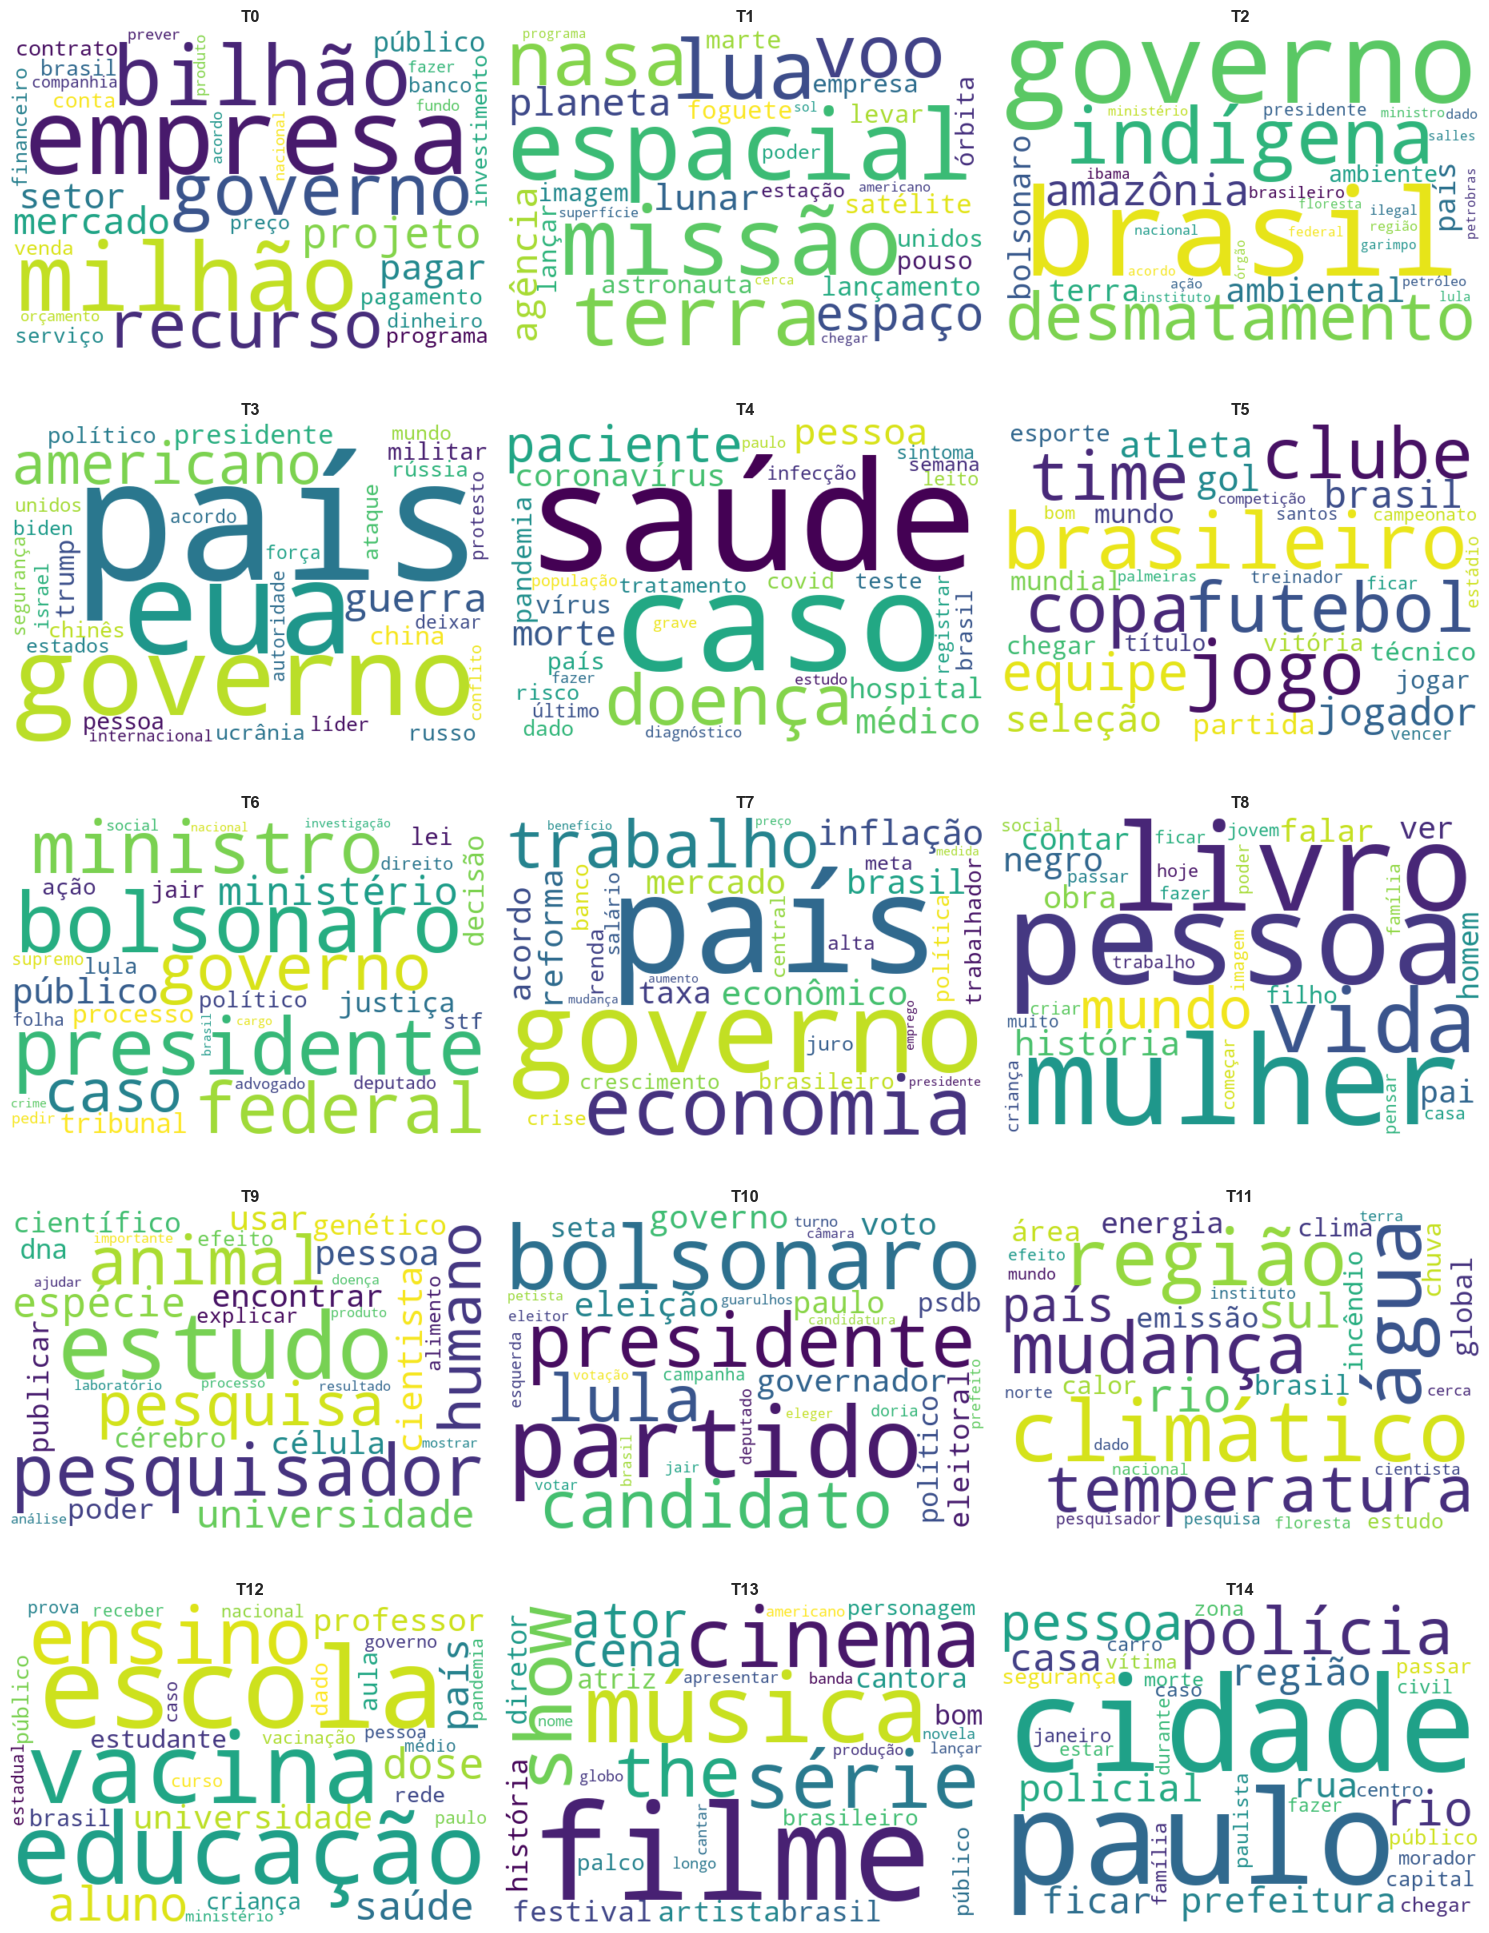

In [15]:
# Cell 13 — Wordclouds (1 por topico)
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

# --- CORRECAO 2026-08-16: filtrar probabilidades nao-positivas antes do WordCloud.
#     `generate_from_frequencies` normaliza dividindo pela frequencia anterior; com
#     duas ou mais palavras de probabilidade 0 no top-30 isso vira 0/0 = NaN e
#     `int(round(NaN))` derruba o notebook inteiro -- uma figura matando um run cujas
#     METRICAS estavam corretas. A condicao nao e bug do modelo: com eta esparso e K
#     no alto da faixa, um topico pode ter menos de 30 palavras com massa. E
#     informacao sobre a esparsidade do phi, entao e reportada em vez de silenciada.
_topicos_rasos = {}
for tid in sorted(topics_keywords):
    # gensim show_topic retorna (palavra, prob); usar prob como freq do wordcloud
    word_probs = {w: float(p) for w, p in model.show_topic(tid, topn=30)
                  if np.isfinite(p) and float(p) > 0}
    if len(word_probs) < 30:
        _topicos_rasos[tid] = len(word_probs)
    if not word_probs:
        axes[tid].text(0.5, 0.5, f"T{tid}\n(sem massa)", ha="center", va="center")
        axes[tid].axis("off")
        continue
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", max_words=30, prefer_horizontal=0.9).generate_from_frequencies(word_probs)
    axes[tid].imshow(wc, interpolation="bilinear")
    axes[tid].set_title(f"T{tid}", fontsize=12, fontweight="bold")
    axes[tid].axis("off")

# Esconde axes nao usados
for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

if _topicos_rasos:
    print(f"NOTA: {len(_topicos_rasos)} de {len(topics_keywords)} topicos tem menos de 30 "
          f"palavras com massa positiva no phi:")
    for _t, _n in sorted(_topicos_rasos.items(), key=lambda kv: kv[1])[:8]:
        print(f"   T{_t}: {_n} palavras")
    print("   Sintoma de phi esparso (eta baixo e/ou K alto). Nao afeta as metricas,")
    print("   que sao calculadas sobre o top-N das keywords, mas vale declarar.")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'lda_wordclouds.png'}")
plt.show()

Salvo: ..\data\output\folha\lda\folha_20260823_100230\lda_keywords_barchart.png


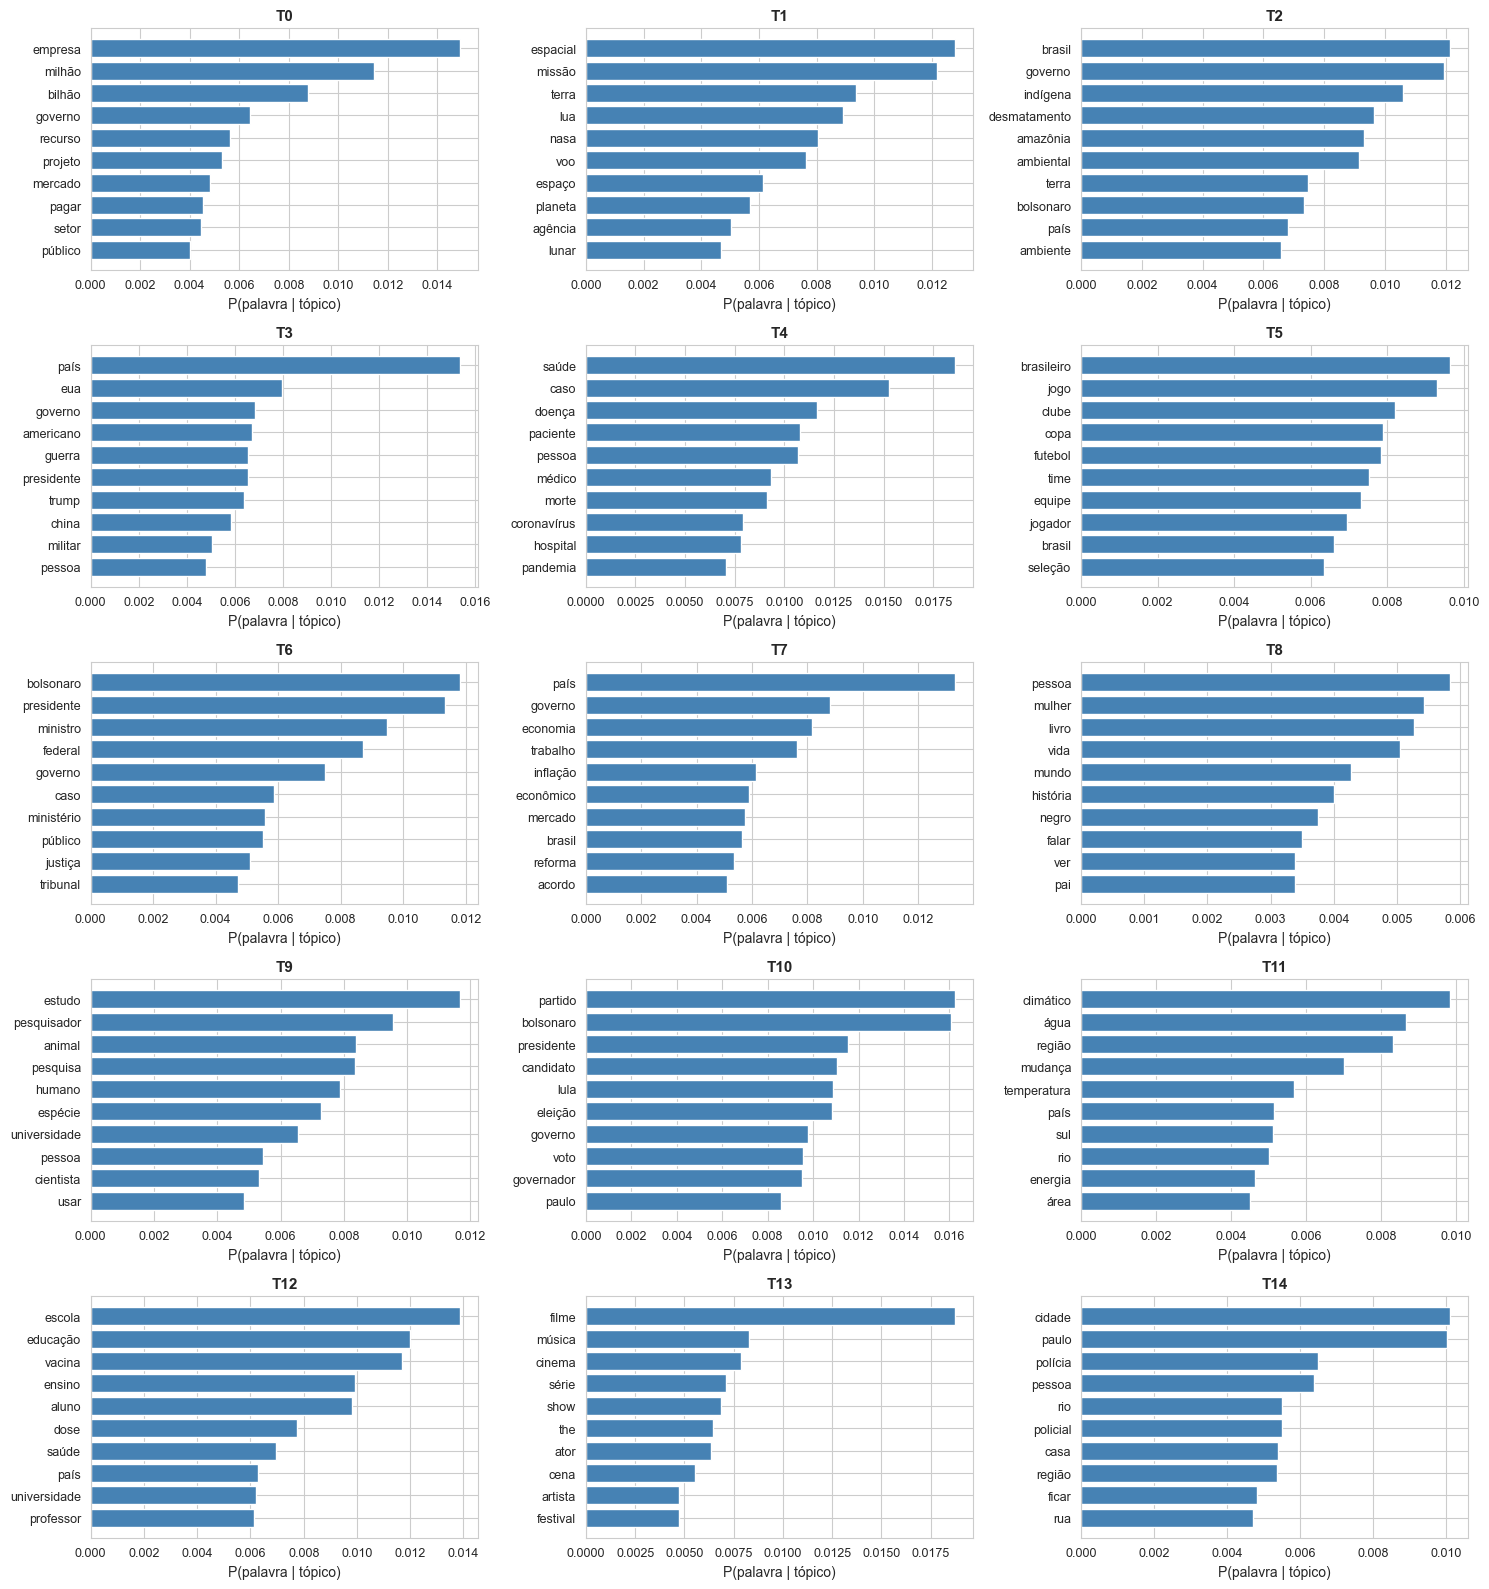

In [16]:
# Cell 14 — Bar chart top-10 keywords per topic
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

for tid in sorted(topics_keywords):
    word_probs = model.show_topic(tid, topn=10)
    words, probs = zip(*word_probs)
    axes[tid].barh(list(words)[::-1], list(probs)[::-1], color="steelblue")
    axes[tid].set_title(f"T{tid}", fontsize=11, fontweight="bold")
    axes[tid].set_xlabel("P(palavra | tópico)")
    axes[tid].tick_params(labelsize=9)

for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_keywords_barchart.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'lda_keywords_barchart.png'}")
plt.show()

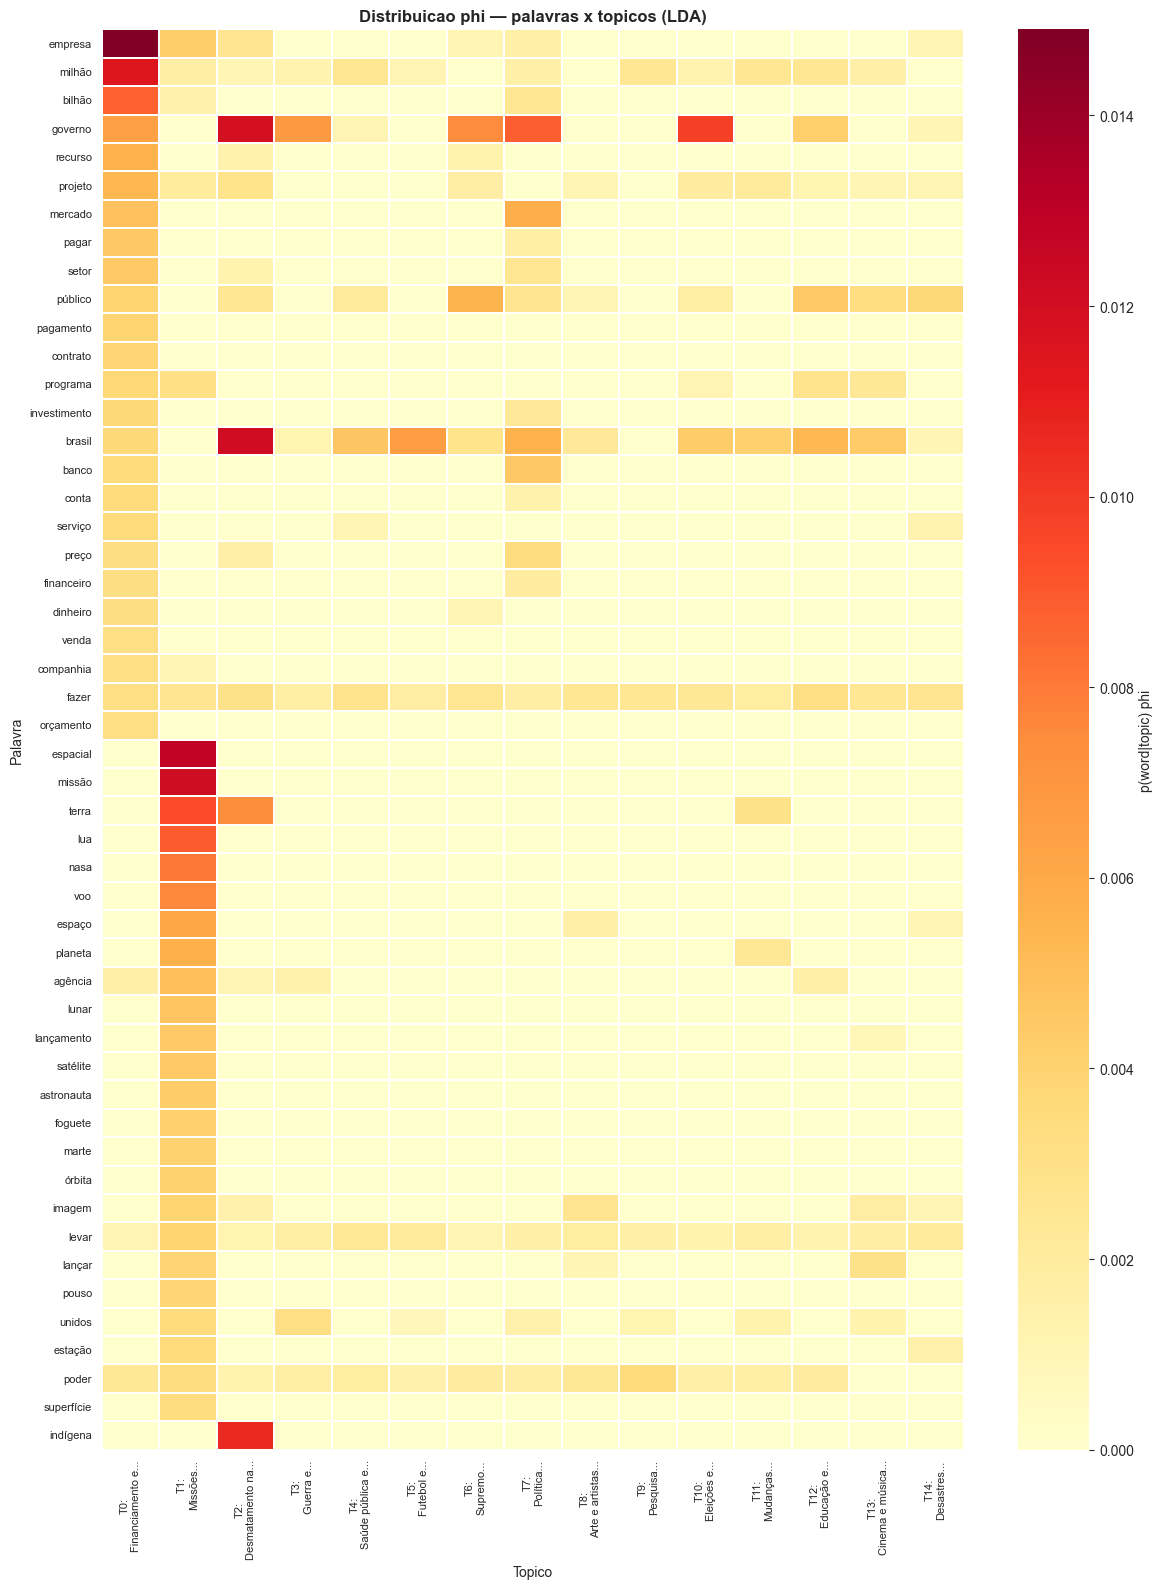

Salvo: ..\data\output\folha\lda\folha_20260823_100230\lda_heatmap_phi.png


In [17]:
import seaborn as sns
# Heatmap phi: top palavras x topicos
_top_n_phi = 25
_all_words = []
for tid in range(BEST_K):
    for w, _ in model.show_topic(tid, topn=_top_n_phi):
        if w not in _all_words:
            _all_words.append(w)
_all_words = _all_words[:min(50, len(_all_words))]

_phi = np.zeros((len(_all_words), BEST_K))
for tid in range(BEST_K):
    _td = dict(model.show_topic(tid, topn=200))
    for wi, w in enumerate(_all_words):
        _phi[wi, tid] = _td.get(w, 0.0)

import textwrap as _tw_lda
_col_labels = [f"T{t}:\n{_tw_lda.shorten(str(globals().get("names",{}).get(t,"")), 18, placeholder="...")}" for t in range(BEST_K)]
_phi_df = pd.DataFrame(_phi, index=_all_words, columns=_col_labels)

fig, ax = plt.subplots(figsize=(max(10, BEST_K * 0.8), max(8, len(_all_words) * 0.32)))
sns.heatmap(_phi_df, cmap="YlOrRd", ax=ax, linewidths=0.15,
            cbar_kws={"label": "p(word|topic) phi"})
ax.set_title("Distribuicao phi — palavras x topicos (LDA)", fontsize=12, fontweight="bold")
ax.set_xlabel("Topico"); ax.set_ylabel("Palavra")
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_heatmap_phi.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'lda_heatmap_phi.png'}")


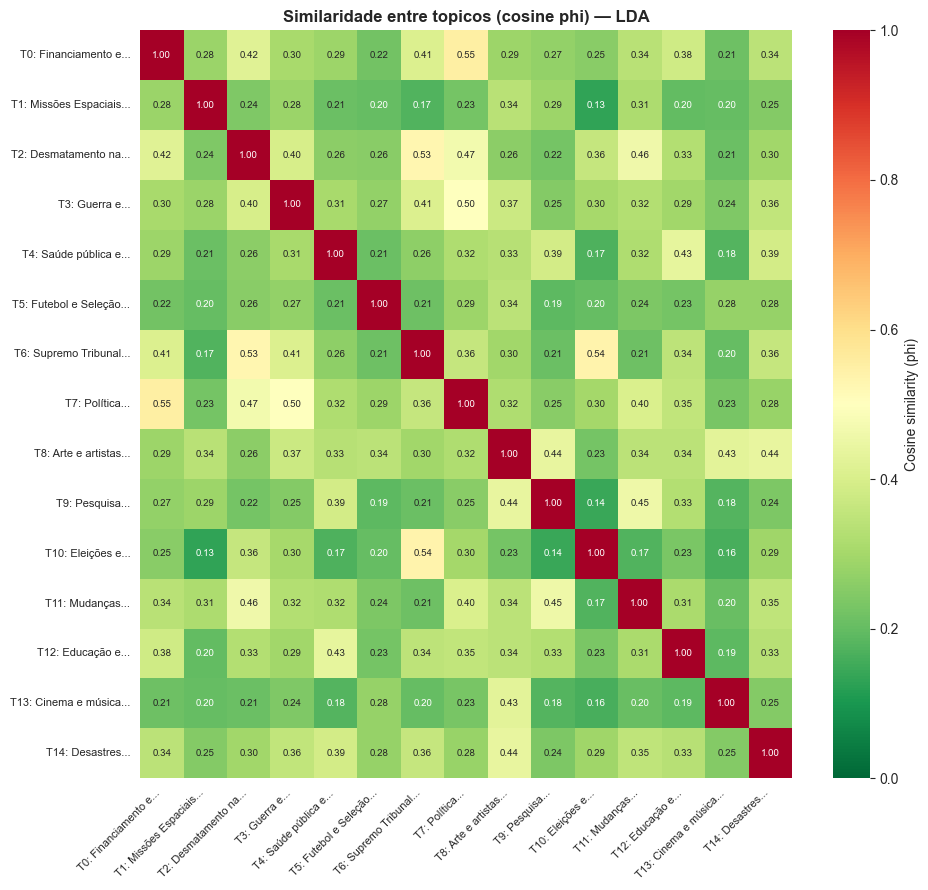

Salvo: ..\data\output\folha\lda\folha_20260823_100230\lda_heatmap_topicos_cosine.png


In [18]:
import seaborn as sns
# Similaridade cosseno entre topicos (vetores phi)
from sklearn.metrics.pairwise import cosine_similarity

_phi_topics = np.zeros((BEST_K, len(dictionary)))
for tid in range(BEST_K):
    for word_id, prob in model.get_topic_terms(tid, topn=len(dictionary)):
        _phi_topics[tid, word_id] = prob

# --- CORRECAO 2026-08-16: sanear NaN antes do cosine_similarity.
#     Um topico "morto" (sem massa) tem a linha do phi normalizada 0/0 -> NaN, e o
#     sklearn recusa a matriz inteira com "Input contains NaN", derrubando o run.
#     E o MESMO fenomeno que a celula de wordclouds ja tratava neste notebook: o
#     tratamento so nao havia sido propagado para ca. Os topicos mortos sao
#     reportados, nao silenciados -- sao diagnostico de K alto demais para o corpus.
_linhas_mortas = [t for t in range(BEST_K)
                  if not np.isfinite(_phi_topics[t]).all() or _phi_topics[t].sum() <= 0]
if _linhas_mortas:
    print(f"ATENCAO: {len(_linhas_mortas)} de {BEST_K} topicos sem massa de "
          f"probabilidade no phi: {_linhas_mortas}")
    print("  Sao topicos degenerados -- sinal de que K esta alto para este corpus.")
    print("  Entram na figura como linha/coluna zerada; declarar no texto.")
_phi_topics = np.nan_to_num(_phi_topics, nan=0.0, posinf=0.0, neginf=0.0)

_cos_sim = cosine_similarity(_phi_topics)
import textwrap as _tw_cos
_tlabels = [f"T{t}: {_tw_cos.shorten(str(globals().get("names",{}).get(t,"")), 20, placeholder="...")}" for t in range(BEST_K)]

fig, ax = plt.subplots(figsize=(max(8, BEST_K * 0.65), max(7, BEST_K * 0.6)))
sns.heatmap(_cos_sim, xticklabels=_tlabels, yticklabels=_tlabels,
            cmap="RdYlGn_r", vmin=0, vmax=1,
            annot=(BEST_K <= 20), fmt=".2f", ax=ax,
            annot_kws={"fontsize": 7},
            cbar_kws={"label": "Cosine similarity (phi)"})
ax.set_title("Similaridade entre topicos (cosine phi) — LDA", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_heatmap_topicos_cosine.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'lda_heatmap_topicos_cosine.png'}")


## 9. Métricas quantitativas

- **c_v** recomputada (validação cruzada do grid)
- **Exclusivity**: 1 - prop. de keywords compartilhadas entre tópicos
- **Topic Diversity**: razão de palavras únicas no consolidado dos top-K
- **Diversity entropy** das distribuições θ doc-tópico (quão espalhadas)

Calculando métricas...


  Perplexidade: 3545.5 (menor = melhor fit)


  NPMI (top-10): +0.1041  |  C_v: 0.6363  |  regime C_v: OK


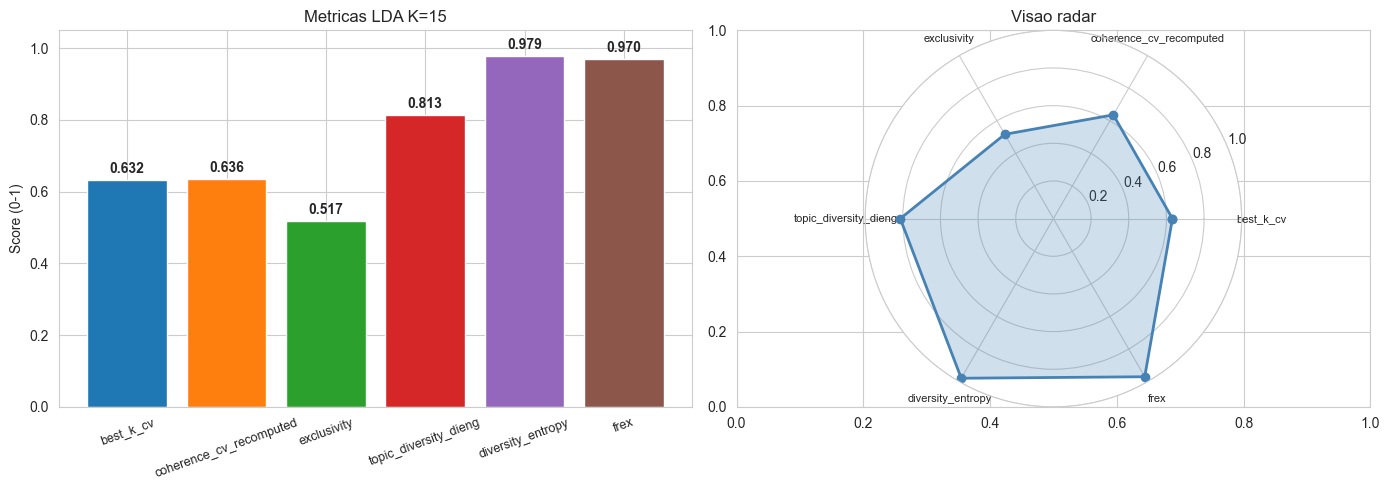

{
  "model": "lda",
  "topic_type": "probabilistic",
  "granularity": "unit",
  "corpus": "folha",
  "corpus_version": "folha_20260628_185652",
  "n_topics": 15,
  "best_k_cv": 0.6320839483264601,
  "exclusivity": 0.5170031630508942,
  "diversity_entropy": 0.978909327259831,
  "topic_diversity_dieng": 0.8133333333333334,
  "frex": 0.9697525238614602,
  "perplexity": 3545.4639095467837,
  "coherence_cv_recomputed": 0.6363193032606068,
  "coherence_npmi": 0.10413871298633331,
  "metrics_top_n": 10,
  "cv_regime_ok": true,
  "cv_window_frac_abaixo": 0.025511237092528852,
  "oov_taxa": 0.0,
  "n_topicos_descartados_coerencia": 0
}


In [19]:
# Cell 16 — Calcula metricas
print("Calculando métricas...")
dominant, full = compute_doc_distributions(model, corpus_bow, k=BEST_K)

# FREX — phi matrix do gensim (K x vocab_size)
_phi = model.get_topics()  # shape (BEST_K, vocab_size)
_vocab_idx = {dictionary[i]: i for i in range(len(dictionary))}
_topic_idx = {tid: tid for tid in range(BEST_K)}
_top_n_metrics = params["evaluation"].get("top_n_keywords_metrics", 20)
frex_mean, frex_per_topic = compute_frex_score(
    topics_keywords, _phi, _vocab_idx, _topic_idx, top_n=_top_n_metrics,
)

# Exclusividade c-TF-IDF (MESMA metrica do BERTopic) - scores da matriz phi completa
_topic_word_scores_lda = {
    tid: {dictionary[i]: float(_phi[tid, i]) for i in range(_phi.shape[1]) if _phi[tid, i] > 0}
    for tid in range(BEST_K)
}
_excl_mean, _excl_per_topic = compute_exclusivity_ctfidf(
    topics_keywords, _topic_word_scores_lda, top_n=_top_n_metrics,
)

# Perplexidade — log_perplexity retorna bound por palavra (ln), exp para perplexidade
perplexity = float(np.exp(-model.log_perplexity(corpus_bow)))
print(f"  Perplexidade: {perplexity:.1f} (menor = melhor fit)")

metrics = {
    "model": "lda",
    "topic_type": "probabilistic",
    "granularity": "unit",
    "corpus": CORPUS_ID,
    "corpus_version": globals().get("CORPUS_VERSION", "n/a"),
    "n_topics": BEST_K,
    "best_k_cv": float(scores.get(BEST_K, 0.0)),
    "exclusivity": float(_excl_mean),
    "diversity_entropy": float(compute_diversity(full)),
    "topic_diversity_dieng": float(compute_topic_diversity(topics_keywords)),
    "frex": float(frex_mean),
    "perplexity": perplexity,
}
metrics["coherence_cv_recomputed"] = float(compute_coherence_cv(topics_keywords, tokenized, dictionary))

# --- ADICAO 2026-08-16 (protocolo de selecao, docs/protocolo-selecao-final-2026-08-16.md).
#     NPMI passa a ser a coerencia que DECIDE; o C_v vira reporte condicionado ao regime
#     de janela (secao 3.0) e o filtro de OOV passa a ser quantificado. Aditivo: nenhum
#     valor preexistente muda. compute_metrics_table e o MESMO codigo chamado pelo
#     _metricas_pos_hoc.py, que preenche os runs ja existentes sem re-executar nada.
_tn_base = max(len(kws) for kws in topics_keywords.values())
_tab = compute_metrics_table(
    topics_keywords, tokenized, dictionary, top_n=_tn_base,
    topic_word_scores=_topic_word_scores_lda,
    topic_word_matrix=_phi, vocab_index=_vocab_idx, topic_index=_topic_idx,
)
assert abs(_tab["cv_bruto"] - metrics["coherence_cv_recomputed"]) < 1e-9, (
    "compute_metrics_table divergiu do calculo direto de C_v - investigar antes de publicar"
)
metrics["coherence_npmi"] = _tab["npmi"]
metrics["metrics_top_n"] = _tab["top_n"]
metrics["cv_regime_ok"] = not _tab["cv_window_degenerado"]
metrics["cv_window_frac_abaixo"] = _tab["cv_window_frac_abaixo"]
metrics["oov_taxa"] = _tab["oov_taxa"]
metrics["n_topicos_descartados_coerencia"] = _tab["n_topicos_descartados"]
_regime = "OK" if metrics["cv_regime_ok"] else "DEGENERADO - nao publicar sob o rotulo C_v"
print("  NPMI (top-%d): %+.4f  |  C_v: %.4f  |  regime C_v: %s"
      % (_tn_base, _tab["npmi"], metrics["coherence_cv_recomputed"], _regime))


# Visualiza num radar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
# NAO acrescentar "coherence_npmi" a esta lista: o NPMI vive em [-1, 1] e o eixo abaixo
# e set_ylim(0, 1.05) - um valor negativo sairia invisivel, sem levantar erro.
metric_keys = ["best_k_cv", "coherence_cv_recomputed", "exclusivity",
               "topic_diversity_dieng", "diversity_entropy", "frex"]
metric_vals = [metrics[k] for k in metric_keys]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
axes[0].bar(metric_keys, metric_vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score (0-1)")
axes[0].set_title(f"Metricas LDA K={BEST_K}")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)
for i, (k, v) in enumerate(zip(metric_keys, metric_vals)):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

# Radar
angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
vals = metric_vals + [metric_vals[0]]
angles_p = angles + [angles[0]]
axes[1] = plt.subplot(122, projection="polar")
axes[1].plot(angles_p, vals, "o-", linewidth=2, color="steelblue")
axes[1].fill(angles_p, vals, alpha=0.25, color="steelblue")
axes[1].set_xticks(angles); axes[1].set_xticklabels(metric_keys, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Visao radar")

plt.tight_layout(); plt.show()
print(json.dumps(metrics, indent=2))

=== Robustez por top-N (LDA) ===
 top_n   NPMI    C_v  Topic_Diversity  Exclusivity   FREX
    10 0.1041 0.6363           0.8133       0.5170 0.9698
    15 0.0938 0.6280           0.8000       0.5113 0.9684
    20 0.0818 0.6072           0.7800       0.4870 0.9656
    25 0.0727 0.5930           0.7653       0.4690 0.9633
    30 0.0634 0.5764           0.7378       0.4508 0.9608
    50 0.0413 0.5341           0.6573       0.4099 0.9539
   100 0.0106 0.4584           0.5493       0.3487 0.9442

C_v top-10 = 0.6363   |   C_v top-20 = 0.6072
conferencia: coherence_cv_recomputed (top-10) = 0.6363


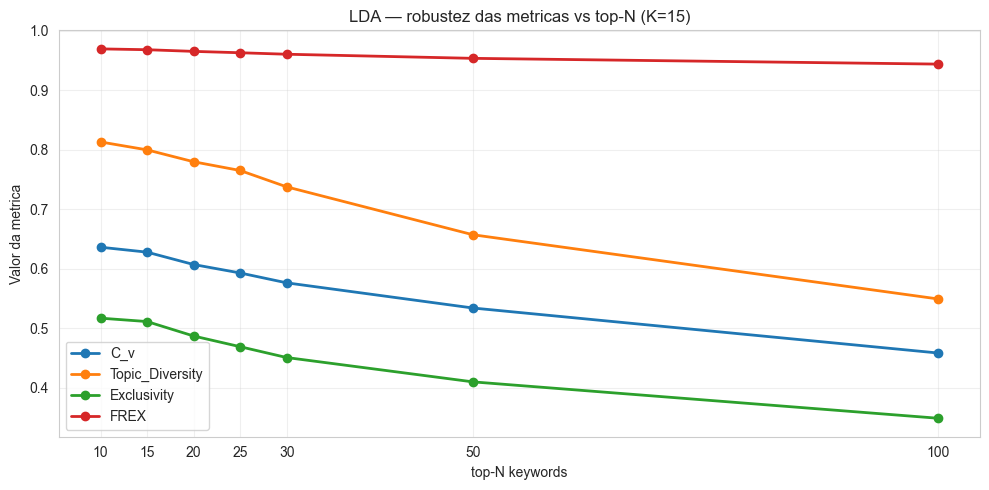

Salvo: ..\data\output\folha\lda\folha_20260823_100230/lda_robustness_topn.csv
Salvo: ..\data\output\folha\lda\folha_20260823_100230/lda_robustness_topn.png


In [20]:
# Cell 16b — Robustez por top-N (espelha a camada 5 do protocolo do BERTopic)
# POR QUE (2026-08-12): o LDA so materializava 10 keywords por topico, entao o C_v
# publicado era top-10 — mas era comparado com o do BERTopic, reportado em top-20.
# Bases distintas. Esta celula recomputa as metricas em cada base do sweep, para que
# a comparacao entre os dois modelos passe a existir na MESMA base.
_sweep_values = params["evaluation"].get("robustness_top_n_sweep", [10, 15, 20, 25, 30, 50, 100])
topics_keywords_full = extract_topics_keywords(model, k=BEST_K, top_n=max(_sweep_values))
_has_frex = "_vocab_idx" in globals() and "_topic_idx" in globals()

_rob_rows = []
for _tn in _sweep_values:
    _kws_at_n = {tid: kws[:_tn] for tid, kws in topics_keywords_full.items()}
    try:
        _cv_n = float(compute_coherence_cv(_kws_at_n, tokenized, dictionary))
    except Exception as _e:
        print(f"  [top-{_tn}] C_v falhou: {_e}")
        _cv_n = float("nan")
    try:
        _npmi_n = float(compute_coherence_npmi(_kws_at_n, tokenized, dictionary))
    except Exception as _e:
        print("  [top-%d] NPMI falhou: %s" % (_tn, _e))
        _npmi_n = float("nan")
    _td_n = float(compute_topic_diversity(_kws_at_n, top_k=_tn))
    _ex_n, _ = compute_exclusivity_ctfidf(topics_keywords_full, _topic_word_scores_lda, top_n=_tn)
    _row = {"top_n": _tn, "NPMI": _npmi_n, "C_v": _cv_n,
            "Topic_Diversity": _td_n, "Exclusivity": float(_ex_n)}
    if _has_frex:
        # FREX fica na tabela por paridade com o BERTopic, mas NAO deve ser lido como
        # nota de modelo: satura ~0.98 por construcao (auditoria 2026-08-01).
        _fx_n, _ = compute_frex_score(topics_keywords_full, _phi, _vocab_idx, _topic_idx, top_n=_tn)
        _row["FREX"] = float(_fx_n)
    _rob_rows.append(_row)

robustness_df = pd.DataFrame(_rob_rows).round(4)
robustness_df.to_csv(f"{out_dir}/lda_robustness_topn.csv", index=False)

print("=== Robustez por top-N (LDA) ===")
print(robustness_df.to_string(index=False))
_cv10 = robustness_df.loc[robustness_df["top_n"] == 10, "C_v"].iloc[0]
_cv20 = robustness_df.loc[robustness_df["top_n"] == 20, "C_v"].iloc[0]
print("")
print(f"C_v top-10 = {_cv10:.4f}   |   C_v top-20 = {_cv20:.4f}")
print(f"conferencia: coherence_cv_recomputed (top-10) = {metrics['coherence_cv_recomputed']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for _col in [c for c in ["C_v", "Topic_Diversity", "Exclusivity", "FREX"] if c in robustness_df]:
    ax.plot(robustness_df["top_n"], robustness_df[_col], marker="o", label=_col, linewidth=2)
ax.set_xlabel("top-N keywords"); ax.set_ylabel("Valor da metrica")
ax.set_title(f"LDA — robustez das metricas vs top-N (K={BEST_K})")
ax.legend(loc="best"); ax.grid(True, alpha=0.3); ax.set_xticks(_sweep_values)
plt.tight_layout()
plt.savefig(f"{out_dir}/lda_robustness_topn.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {out_dir}/lda_robustness_topn.csv")
print(f"Salvo: {out_dir}/lda_robustness_topn.png")


In [21]:
# Cell 16c — A2: estabilidade multi-seed (protocolo secao 1.1)
# DECISAO 2026-08-23: nao roda mais em nenhum braco. A selecao e a publicacao
# incidem sobre a seed 42, apenas (protocolo secao 1.1) — nao ha "estabilidade
# entre seeds" a medir quando so existe uma seed. O refit em 3 seeds que este
# passo fazia (A2, "Estabilidade dos topicos a K fixo") era o unico ponto do
# notebook que ainda levava 3x LdaMulticore(workers=None) sequenciais — a
# causa mais provavel do kernel morrer ~84min dentro da execucao (ledger
# Task 8, 2026-08-23: 'pressao de memoria dos 15 workers acumulada nos
# refits da etapa multi-seed').
print("Estabilidade multi-seed: DESATIVADA (protocolo secao 1.1 — selecao roda so sobre a seed 42).")


Estabilidade multi-seed: DESATIVADA (protocolo secao 1.1 — selecao roda so sobre a seed 42).


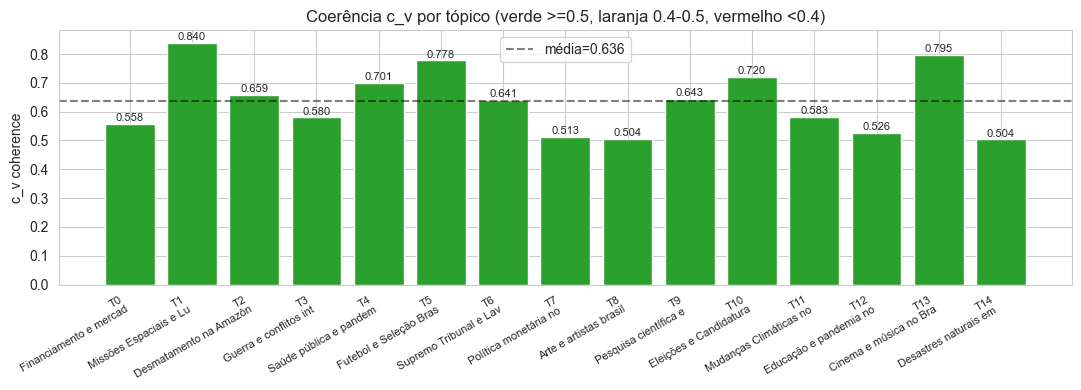

In [22]:
# Cell 17 — c_v por topico (nao so media)
from gensim.models import CoherenceModel
cm = CoherenceModel(
    topics=[topics_keywords[tid] for tid in sorted(topics_keywords)],
    texts=tokenized, dictionary=dictionary, coherence="c_v",
)
per_topic_cv = cm.get_coherence_per_topic()

fig, ax = plt.subplots(figsize=(11, 4))
tids = sorted(topics_keywords)
labels = [f"T{tid}\n{names[tid][:22]}" for tid in tids]
bars = ax.bar(tids, per_topic_cv, color=["#2ca02c" if c >= 0.5 else "#ff7f0e" if c >= 0.4 else "#d62728" for c in per_topic_cv])
ax.axhline(np.mean(per_topic_cv), color="black", linestyle="--", alpha=0.5, label=f"média={np.mean(per_topic_cv):.3f}")
ax.set_xticks(tids); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("c_v coherence"); ax.set_title("Coerência c_v por tópico (verde >=0.5, laranja 0.4-0.5, vermelho <0.4)")
ax.legend()
for bar, c in zip(bars, per_topic_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{c:.3f}",
            ha="center", fontsize=8)
plt.tight_layout(); plt.show()

## 10. Distribuição de documentos por tópico

Mostra balanceamento dos clusters. Distribuição muito desigual pode indicar:
- 1 tópico "lixo" capturando outliers
- K muito alto fragmentando o sinal

Salvo: ..\data\output\folha\lda\folha_20260823_100230\lda_docs_por_topico.png


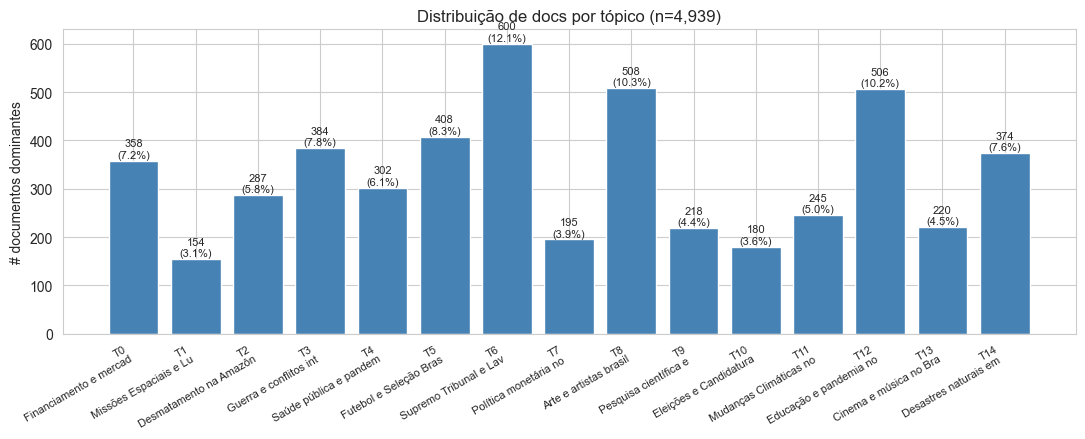


Docs por tópico — descritivas: {'count': 15.0, 'mean': 329.26666666666665, 'std': 134.5561309675348, 'min': 154.0, '25%': 219.0, '50%': 302.0, '75%': 396.0, 'max': 600.0}


In [23]:
# Cell 18 — Bar chart docs por topico
topic_doc_counts = pd.Series(dominant).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = [f"T{tid}\n{names[tid][:22]}" for tid in topic_doc_counts.index]
bars = ax.bar(topic_doc_counts.index, topic_doc_counts.values, color="steelblue")
ax.set_xticks(topic_doc_counts.index); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("# documentos dominantes")
ax.set_title(f"Distribuição de docs por tópico (n={len(docs):,})")
for bar, c in zip(bars, topic_doc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + max(topic_doc_counts)*0.01,
            f"{c:,}\n({c/len(docs)*100:.1f}%)", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_docs_por_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'lda_docs_por_topico.png'}")
plt.show()

print(f"\nDocs por tópico — descritivas: {topic_doc_counts.describe().to_dict()}")

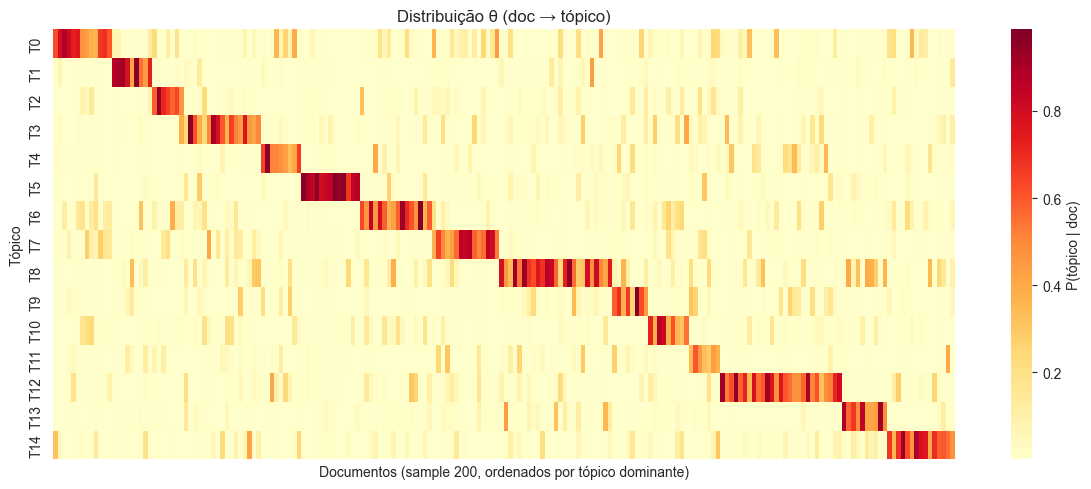

In [24]:
# Cell 19 — Heatmap theta (doc x topico) — sample
sample_n = min(200, len(full))
sample_idx = np.random.RandomState(42).choice(len(full), sample_n, replace=False)
theta_sample = np.array([full[i] for i in sample_idx])

# Sort sample by dominant topic for readability
sample_dom = theta_sample.argmax(axis=1)
order = np.argsort(sample_dom)
theta_sorted = theta_sample[order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(theta_sorted.T, cmap="YlOrRd", cbar_kws={"label": "P(tópico | doc)"},
            xticklabels=False, yticklabels=[f"T{i}" for i in range(BEST_K)], ax=ax)
ax.set_xlabel(f"Documentos (sample {sample_n}, ordenados por tópico dominante)")
ax.set_ylabel("Tópico"); ax.set_title("Distribuição θ (doc → tópico)")
plt.tight_layout(); plt.show()

## t-SNE do espaço de tópicos (θ)

Reduz a matriz θ (N×K) a 2D via t-SNE. Gera PNG colorido por tópico dominante e versão HTML interativa com hover do texto.

Calculando t-SNE sobre matriz theta...


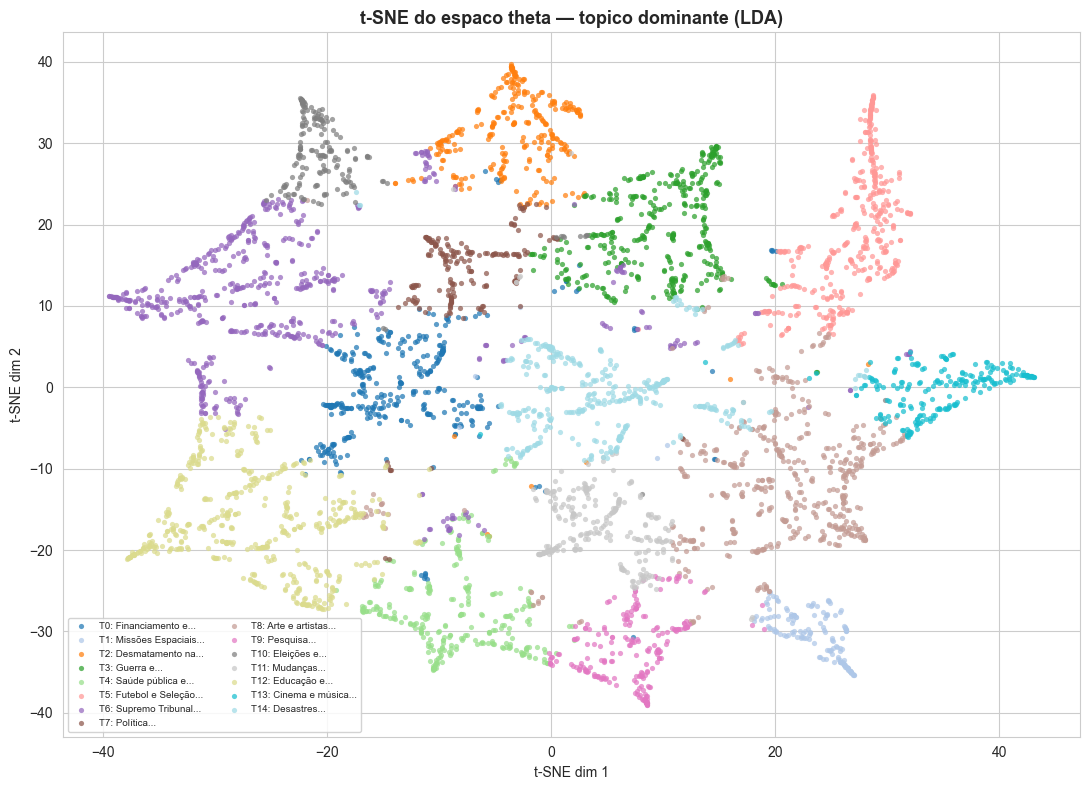

Salvo: ..\data\output\folha\lda\folha_20260823_100230\lda_tsne_theta_topico.png


Salvo: ..\data\output\folha\lda\folha_20260823_100230\lda_tsne_theta_interactive.html


In [25]:
import plotly.express as px
from sklearn.manifold import TSNE

_theta_mat = np.array(full)  # (n_docs, K)
_texts_lda = [t[:100] + "..." if len(t) > 100 else t for t in docs]

print("Calculando t-SNE sobre matriz theta...")
_tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=500)
_theta_2d = _tsne.fit_transform(_theta_mat)

_cmap_lda = plt.get_cmap("tab20", max(BEST_K, 1))

# PNG por topico dominante
fig, ax = plt.subplots(figsize=(11, 8))
for tid in range(BEST_K):
    _mm = np.array(dominant) == tid
    if _mm.any():
        import textwrap as _tw_u
        _nm = _tw_u.shorten(str(names.get(tid, "")), 20, placeholder="...")
        ax.scatter(_theta_2d[_mm, 0], _theta_2d[_mm, 1],
                   c=[_cmap_lda(tid)], s=14, alpha=0.72, linewidths=0,
                   label=f"T{tid}: {_nm}")
ax.set_title("t-SNE do espaco theta — topico dominante (LDA)", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_tsne_theta_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'lda_tsne_theta_topico.png'}")

# HTML interativo por topico dominante
import textwrap as _tw_u2
_tsne_df_lda = pd.DataFrame({
    "x": _theta_2d[:, 0], "y": _theta_2d[:, 1],
    "Texto": _texts_lda,
    "Topico": [f"T{t}: {_tw_u2.shorten(str(names.get(t,"")), 25, placeholder="...")}" for t in dominant],
})
fig_u = px.scatter(
    _tsne_df_lda, x="x", y="y", color="Topico",
    hover_data={"x": False, "y": False, "Texto": True},
    title="t-SNE espaco theta — topico dominante (interativo, LDA)",
    labels={"x": "t-SNE dim 1", "y": "t-SNE dim 2"}, opacity=0.72,
)
fig_u.update_traces(marker_size=5)
_out_u = OUTPUT_DIR / "lda_tsne_theta_interactive.html"
fig_u.write_html(_out_u)
fig_u.show()
print(f"Salvo: {_out_u}")


## 11. Cross-tab tópico × categoria Folha

Folha tem categorias editoriais (ex: `politica`, `economia`, `esporte`, `mundo`).
Concentração de um tópico em uma categoria valida coerência semântica.


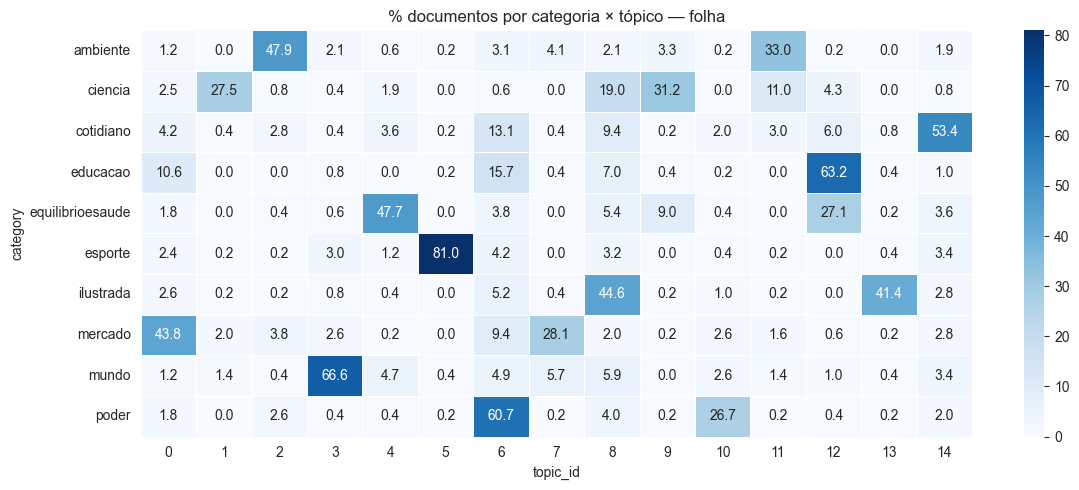

In [26]:
# Heatmap tópico × categoria — folha
if 'category' in df.columns:
    df_topic = df[['category']].copy()
    df_topic['topic_id'] = dominant
    df_topic = df_topic[df_topic['topic_id'] != -1]
    pivot = df_topic.groupby(['category', 'topic_id']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*0.8), max(4, len(pivot)*0.5)))
    sns.heatmap(pivot_pct.round(1), annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax)
    ax.set_title('% documentos por categoria × tópico — folha')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'lda_topic_category.png', dpi=150)
    plt.show()
else:
    print('Coluna category nao encontrada')


## 12. pyLDAvis — visualização interativa

Visualização canônica do LDA (Sievert & Shirley 2014). Mostra:
- **Esquerda**: tópicos como círculos no plano 2D (PCA do espaço inter-tópico). Tamanho = prevalência. Distância = dissimilaridade.
- **Direita**: bar chart das top-30 palavras do tópico selecionado, com slider λ controlando "exclusivity vs frequency" (Bischof & Airoldi 2016 — base do FREX score).

In [27]:
# Cell 21 — pyLDAvis (interativo, salva HTML)
import pyLDAvis
import pyLDAvis.gensim_models as gensim_pyLDAvis

pyLDAvis.enable_notebook()

print("Preparing pyLDAvis (~30s)...")
vis_data = gensim_pyLDAvis.prepare(model, corpus_bow, dictionary, sort_topics=False)
out_html = f"{out_dir}/lda_pyldavis_K{BEST_K}.html"
pyLDAvis.save_html(vis_data, out_html)
print(f"saved: {out_html}")
vis_data

Preparing pyLDAvis (~30s)...


saved: ..\data\output\folha\lda\folha_20260823_100230/lda_pyldavis_K15.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.054692 -0.120561       1        1   8.243382
1     -0.127016  0.045179       2        1   3.101096
2      0.071128 -0.101226       3        1   5.663387
3      0.043997  0.033876       4        1   7.231658
4     -0.112359 -0.072070       5        1   6.126450
5      0.028886  0.165676       6        1   6.109193
6      0.167382 -0.026476       7        1  11.809760
7      0.052610 -0.095869       8        1   4.923798
8     -0.083277  0.135969       9        1  10.897246
9     -0.197842 -0.039208      10        1   5.088847
10     0.191863  0.005715      11        1   5.070175
11    -0.131970 -0.094053      12        1   5.654441
12    -0.011893 -0.094854      13        1   9.195949
13     0.010215  0.230081      14        1   3.310246
14     0.043584  0.027820      15        1   7.574372, topic_info=            Term         Freq        Total Category  logprob  loglift
1241   bolsonaro  4669.000000  4669.000000  Default  30.0000  30.0000
65         saúde  3537.000000  3537.000000  Default  29.0000  29.0000
201       escola  2562.000000  2562.000000  Default  28.0000  28.0000
313      partido  1930.000000  1930.000000  Default  27.0000  27.0000
330   presidente  5623.000000  5623.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
2069        obra   306.047944  1261.533520  Topic15  -6.0310   1.1641
127         caso   397.933025  5392.231767  Topic15  -5.7685  -0.0260
207        estar   337.455987  3099.868263  Topic15  -5.9333   0.3627
1329       fazer   327.966982  4169.613301  Topic15  -5.9618   0.0377
586      durante   325.424783  3279.746461  Topic15  -5.9696   0.2700

[1331 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
1902       9  0.990109     aaron
8435      10  0.991340    abelha
11177      7  1.001869      abin
16308      5  0.959309   abramge
2982       9  0.991907  abstrato
...      ...       ...       ...
77        11  0.057284    último
77        12  0.097489    último
77        13  0.088238    último
77        14  0.040561    último
77        15  0.066890    último

[6636 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])

## 13. Top documentos por tópico

Mostra os 3 docs com maior probabilidade em cada tópico — verificação qualitativa direta da semântica.

In [28]:
# Cell 22 — Top 3 docs por topico
TOP_N_DOCS = 3
TRUNC = 200

theta_arr = np.array(full)
print("Top docs por topico (truncados em 200 chars):\n")
for tid in sorted(topics_keywords):
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:TOP_N_DOCS]
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    for rank, idx in enumerate(top_idx, 1):
        prob = theta_arr[idx, tid]
        cat = df.iloc[idx]["category"]
        text = df.iloc[idx]["message"][:TRUNC].replace("\n", " ")
        print(f"  #{rank} (P={prob:.3f}, cat={cat}): {text}...")
        print()

Top docs por topico (truncados em 200 chars):

=== T0 [Financiamento e mercado financeiro brasileiro] ===
  keywords: ['empresa', 'milhão', 'bilhão', 'governo', 'recurso', 'projeto', 'mercado', 'pagar']

  #1 (P=0.988, cat=mercado): Por meio da medida provisória 1.005, a Caixa Econômica Federal está liberando em 2022 uma modalidade especial de retirada dos valores do FGTS (Fundo de Garantia do Tempo de Serviço): o saque extraordi...

  #2 (P=0.967, cat=mercado): O DIP (do inglês debtor-in-possesion financing, ou "financiamento do devedor em posse"), modelo de financiamento estudado pela Americanas, é usado apenas em recuperações judiciais. O recurso passou a ...

  #3 (P=0.958, cat=mercado): Gigantes de diversos setores da economia brasileira, com capital aberto na Bolsa, devem ser atingidos pela decisão do CMN (Conselho Monetário Nacional) de fechar as brechas para a emissão de títulos d...

=== T1 [Missões Espaciais e Lua] ===
  keywords: ['espacial', 'missão', 'terra', 'lua', 'nasa'

## 14. Export + relatório qualitativo

Gera os CSVs canônicos (`lda_results.csv`, `lda_topics_for_eval.csv`, `lda_metrics.csv`).

In [29]:
# Cell 23 — Export final
os.makedirs(out_dir, exist_ok=True)

export_results(
    topics=dominant, probs=full, names=names, texts=docs,
    output_path=f"{out_dir}/lda_results.csv",
    topic_type="probabilistic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="lda", output_path=f"{out_dir}/lda_topics_for_eval.csv",
)
# --- ADICAO 2026-08-15: procedencia de execucao do LdaMulticore ---
# O resultado depende de `workers` (updateafter = chunksize * workers decide o
# regime online-vs-batch) E do hardware disponivel na hora do fit — medido:
# workers=15 deu C_v 0,4323 com 16 nucleos livres e 0,4301 com 4. Sem registrar
# isso, uma divergencia futura vira misterio, como aconteceu com os grids
# anteriores a 2026-07-20. Ver a nota em _helpers.grid_search_k.
_lda_cpu_count = os.cpu_count()
_lda_workers = max(1, (_lda_cpu_count or 2) - 1)  # o que LdaMulticore usa com workers=None
metrics_full = {**metrics, "k_grid_scores": json.dumps(scores),
                # curva de NPMI sobre a faixa de K — eixo de ordenacao do protocolo
                # 2026-08-16 e chave de validade do cache (ver Cell 8).
                "k_npmi_scores": json.dumps(npmi_scores),
                # curva de Diversity sobre a faixa de K — segundo eixo da fronteira
                # de Pareto do protocolo 2026-08-22 (secao 1.5).
                "k_diversity_scores": json.dumps(div_scores),
                "k_perplexity_scores": json.dumps(perplexity_scores), "grid_passes": 20,
                "lda_workers": _lda_workers, "cpu_count": _lda_cpu_count,
                "lda_workers_origem": "default (cpu_count-1)",
                "best_alpha": str(best_alpha), "best_eta": str(best_eta)}
pd.DataFrame([metrics_full]).to_csv(f"{out_dir}/lda_metrics.csv", index=False)
# Cache acessível em próximos runs (foi salvo no run dir; copia pro diretório-base)
pd.DataFrame([metrics_full]).to_csv(f"{BASE_OUTPUT_DIR}/lda_metrics.csv", index=False)

print(f"CSVs em {out_dir}/:")
for f in ["lda_results.csv", "lda_topics_for_eval.csv", "lda_metrics.csv"]:
    sz = os.path.getsize(f"{out_dir}/{f}")
    print(f"  {f} ({sz/1024:.0f} KB)")
print(f"  lda_pyldavis_K{BEST_K}.html")

CSVs em ..\data\output\folha\lda\folha_20260823_100230/:
  lda_results.csv (26229 KB)
  lda_topics_for_eval.csv (2 KB)
  lda_metrics.csv (2 KB)
  lda_pyldavis_K15.html


In [30]:
# Cell 24 — Exclusividade + n_docs por tópico (ranking p/ o assessor de calibração)
# Espelha o bertopic_exclusividade_ranking.csv. Reusa os MESMOS topic_word_scores
# nativos (phi/beta) do cálculo de exclusividade do lda_metrics.csv, p/ o ranking
# BATER com as métricas (mesma convenção do BERTopic). Coletado pelo advisor via
# glob *exclusividade_ranking.csv.
from _helpers import export_exclusividade_ranking

excl_rank_df = export_exclusividade_ranking(
    topics_keywords=topics_keywords,
    dominant_per_doc=dominant,
    names=names,
    topic_word_scores=_topic_word_scores_lda,
    out_path=f"{out_dir}/lda_exclusividade_ranking.csv",
    top_n=params["evaluation"].get("top_n_keywords_metrics", 20),
)
print("lda_exclusividade_ranking.csv (exclusividade desc):")
print(excl_rank_df.to_string(index=False))

lda_exclusividade_ranking.csv (exclusividade desc):
 topic_id                                      topic_name  exclusividade  n_docs
       13                       Cinema e música no Brasil       0.830668     220
        1                         Missões Espaciais e Lua       0.764549     154
        5                    Futebol e Seleção Brasileira       0.719240     408
       12                   Educação e pandemia no Brasil       0.650537     506
        4              Saúde pública e pandemia no Brasil       0.594665     302
       10                         Eleições e Candidaturas       0.574004     180
        2 Desmatamento na Amazônia e políticas ambientais       0.480922     287
       11                    Mudanças Climáticas no Mundo       0.446887     245
        9              Pesquisa científica e saúde humana       0.443982     218
        3               Guerra e conflitos internacionais       0.416422     384
        7                    Política monetária no Brasil

In [31]:
# Cell 24 — Relatorio qualitativo (template)
md = qualitative_report(topics_keywords, names)
print(md)

# Qualitative report
**Total topics:** 15
## Tópicos coesos
_(preencher manualmente: tópicos com keywords semanticamente próximas e tema único)_
## Tópicos genéricos / discurso
_(preencher manualmente: keywords genéricas, sem tema concreto)_
## Tópicos lixo / boilerplate
_(preencher manualmente: keywords são fórmulas, hashtags, headers, etc.)_
## Redundâncias
_(preencher manualmente: tópicos diferentes que cobrem o mesmo tema)_
## Candidatos a stop word
_(preencher manualmente: termos repetidos em 3+ tópicos sem agregar diferenciação)_
## Tabela de tópicos
| ID | Nome | Top keywords |
|---|---|---|
| T0 | Financiamento e mercado financeiro brasileiro | empresa, milhão, bilhão, governo, recurso, projeto, mercado, pagar, setor, público |
| T1 | Missões Espaciais e Lua | espacial, missão, terra, lua, nasa, voo, espaço, planeta, agência, lunar |
| T2 | Desmatamento na Amazônia e políticas ambientais | brasil, governo, indígena, desmatamento, amazônia, ambiental, terra, bolsonaro, país, amb

## Próximos passos
- Comparar com BERTopic (`01_bertopic_folha.ipynb`) — triangulação LDA × BERTopic
- Analisar evolução temporal de tópicos (coluna `date` disponível)
